# Deja Swing: The Search for Batter Adaptation

### Research question and scope

This notebook examines whether repeated exposure to a pitch is associated with changes in swing geometry. Public Statcast records are used to reconstruct pitch sequences and estimate distributions over hitter-specific correction associations. Negative controls and later-season tests assess the interpretation and persistence of these associations.

Player estimates are reported as posterior distributions, with uncertainty in comparisons and ranks. The original primary model is evaluated on a temporal holdout. Any additional analyses specified after inspecting that holdout are labeled exploratory.

**Run:** select **Kernel → Restart Kernel and Run All Cells**. The default walkthrough runs offline from the frozen data and generated model outputs included in this project. It regenerates the scientific figures, runs a small synthetic example, and demonstrates real-player comparisons. The optional full pipeline refits models using frozen data and takes longer.

**Reading time:** approximately 15 minutes. **Units:** positive $\lambda$ means lower unexpected swing deviation per one unit of $\log(1 + \text{prior exposure})$. It does not mean a percentage of error corrected, and it is not an identified causal learning rate.

In [1]:
from pathlib import Path
import sys, json, subprocess, io, os, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "deja-swing-matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works from either the repository root or the notebooks/ directory.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "config/analysis.json").exists() and (p / "src/pipeline.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook inside the Deja Swing repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CONFIG = json.loads((ROOT / "config/analysis.json").read_text())
SEED = CONFIG["seed"]
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def table(name):
    return pd.read_csv(ROOT / "results/tables" / name)

def document(name):
    return json.loads((ROOT / name).read_text())

def posterior(season=2025):
    with np.load(ROOT / f"results/posterior/adaptation_{season}.npz") as archive:
        return dict(archive)

print(f"Project: {ROOT.name} | Seed: {SEED} | Default mode: frozen offline replay")

Matplotlib is building the font cache; this may take a moment.


Project: mlb-batter-adaptation | Seed: 20260921 | Default mode: frozen offline replay


## 1. Reproducing the analysis

The repository separates source retrieval, current-pitch baseline fitting, adaptation estimation, and validation. The frozen snapshot and source manifests record the observed data coverage.

`RUN_FULL_PIPELINE = True` below recomputes features, models, validation, and checksums from frozen raw partitions. It does not fetch new data. Default execution uses the saved outputs.

In [2]:
RUN_FULL_PIPELINE = False
if RUN_FULL_PIPELINE:
    subprocess.run([sys.executable, "-m", "src.pipeline", "all"], cwd=ROOT, check=True)
    for entry in ["17_supplementary_validation.py", "18_matched_exposure.py", "19_percentile_stability.py",
                  "11_pairwise_comparisons.py", "build_report.py"]:
        subprocess.run([sys.executable, str(ROOT / "scripts" / entry)], cwd=ROOT, check=True)
    subprocess.run([sys.executable, "-m", "src.pipeline", "freeze"], cwd=ROOT, check=True)

required = ["results/tables/batter_adaptation_posteriors.csv",
            "results/tables/robustness.csv", "results/tables/persistence.json",
            "results/posterior/adaptation_2025.npz", "results/tables/percentile_stability.csv"]
missing = [path for path in required if not (ROOT / path).exists()]
if missing:
    raise FileNotFoundError("Missing generated outputs; run make reproduce first: " + ", ".join(missing))

sample = document("results/logs/sample.json")
display(Markdown(f"**Frozen sample:** {sample['raw_pitches']:,} pitch-level records across "
                 f"{sample['raw_games']:,} games, {sample['start']} through {sample['end']}."))
display(pd.DataFrame({"Season": list(sample["seasons"]),
                      "Pitch-level records": list(sample["seasons"].values())}).set_index("Season"))

**Frozen sample:** 2,433,934 pitch-level records across 8,271 games, 2023-07-14 through 2026-09-20.

,Pitch-level records
Season,
2023,319018
2024,711899
2025,712528
2026,690489


In [3]:
primary = table("robustness.csv").query("specification == 'exposure_pitcher'")
transport = document("results/tables/holdout_prediction.json")
loss_verb = "reduce" if transport["mse_improvement_pct"] >= 0 else "increase"
loss_ci = transport["ci90"] if loss_verb == "reduce" else [-transport["ci90"][1], -transport["ci90"][0]]
result_lines = ["## Main results", "",
    "Positive correction associations mean less unexpected deviation with repeated exposure."]
for row in primary.itertuples():
    result_lines.append(f"- **{int(row.season)}:** {row.mu_median:.3f} deviation SD per log-exposure unit "
                       f"(90% credible interval {row.mu_low:.3f} to {row.mu_high:.3f}; {int(row.players)} hitters).")
component_rank = table("percentile_stability.csv").query(
    "specification == 'absz_swing_length__log_exposure_pitcher__n500' and method == 'pooled' and endpoint == 'spearman'").iloc[0]
result_lines += ["", f"Individual 2025 slopes **{loss_verb}** 2026 conditional prediction MSE by "
    f"**{abs(transport['mse_improvement_pct']):.3f}%** (90% interval "
    f"{loss_ci[0]:.3f}% to {loss_ci[1]:.3f}%).",
    "", "These estimates describe exposure associations. The controls, measurement limitations, "
    "and persistence checks below assess their interpretation as adaptation.",
    "", f"**Exploratory component result:** Swing-length score ranks correlate "
    f"**{component_rank.estimate:.3f}** across seasons among {int(component_rank.shared_players)} hitters "
    f"with at least 500 swings in both periods (90% interval {component_rank.ci90_low:.3f} to "
    f"{component_rank.ci90_high:.3f}). The complete percentile search, failed internal replication, "
    "and similarly stable future-exposure control are reported in Section 11."]
display(Markdown("\n".join(result_lines)))

## Main results

Positive correction associations mean less unexpected deviation with repeated exposure.
- **2025:** 0.035 deviation SD per log-exposure unit (90% credible interval 0.028 to 0.043; 587 hitters).
- **2026:** 0.030 deviation SD per log-exposure unit (90% credible interval 0.022 to 0.037; 591 hitters).

Individual 2025 slopes **increase** 2026 conditional prediction MSE by **0.005%** (90% interval 0.001% to 0.008%).

These estimates describe exposure associations. The controls, measurement limitations, and persistence checks below assess their interpretation as adaptation.

**Exploratory component result:** Swing-length score ranks correlate **0.195** across seasons among 203 hitters with at least 500 swings in both periods (90% interval 0.086 to 0.307). The complete percentile search, failed internal replication, and similarly stable future-exposure control are reported in Section 11.

Regenerated 16 figures as PNG and vector PDF in results/figures/.


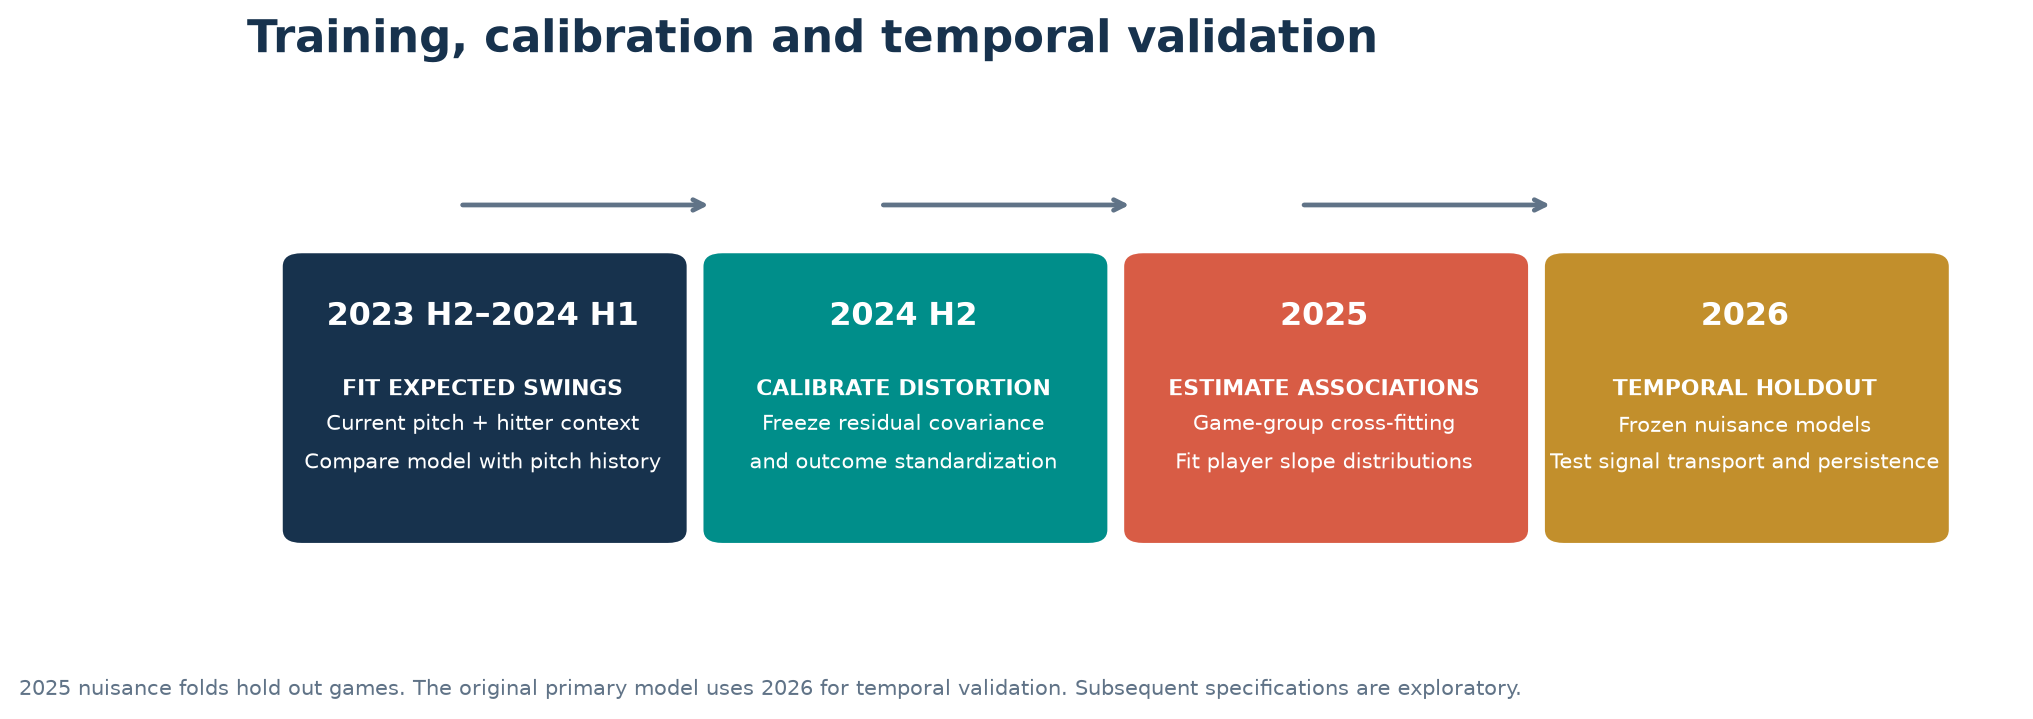

In [4]:
from src.visualization.figures import make_figures
FIGURES = make_figures(ROOT)

def show_figure(name):
    display(Image(filename=str(FIGURES[name]), width=1150))

print(f"Regenerated {len(FIGURES)} figures as PNG and vector PDF in results/figures/.")
show_figure("01_research_timeline")

The current-pitch baseline trains before July 2024. July–December 2024 calibrates the residual covariance. The 2025 nuisance regressions hold out whole games; other games later in 2025 may train a given fold. For the original primary model, **2026 is a temporal holdout**, predicted using 2025 nuisance models with fixed choices. This separation does not extend to additional exploratory specifications chosen after inspecting 2026.

Powers and Yurko (2026), *Swinging, Fast and Slow*, establish the importance of context when interpreting swing tracking. This project studies conditional exposure slopes and their uncertainty. Steinhardt and Borowiak (2025), *Hitter and Catcher Adaptation in Major League Baseball*, already study current-pitch-adjusted performance, repeated pitches, and heterogeneous adjustment. The extension considered here combines mechanics-based deviations, uncertainty in player comparisons, and negative controls. See [the literature review](../literature/related_work.md) for overlaps and differences.

## 2. Tracking coverage

A hitter can miss repeatedly while changing swing geometry. The coverage audit counts every recorded pitch, swing, whiff, and contact swing before model filtering. Empty measurements remain missing. Availability can vary by season and contact status.

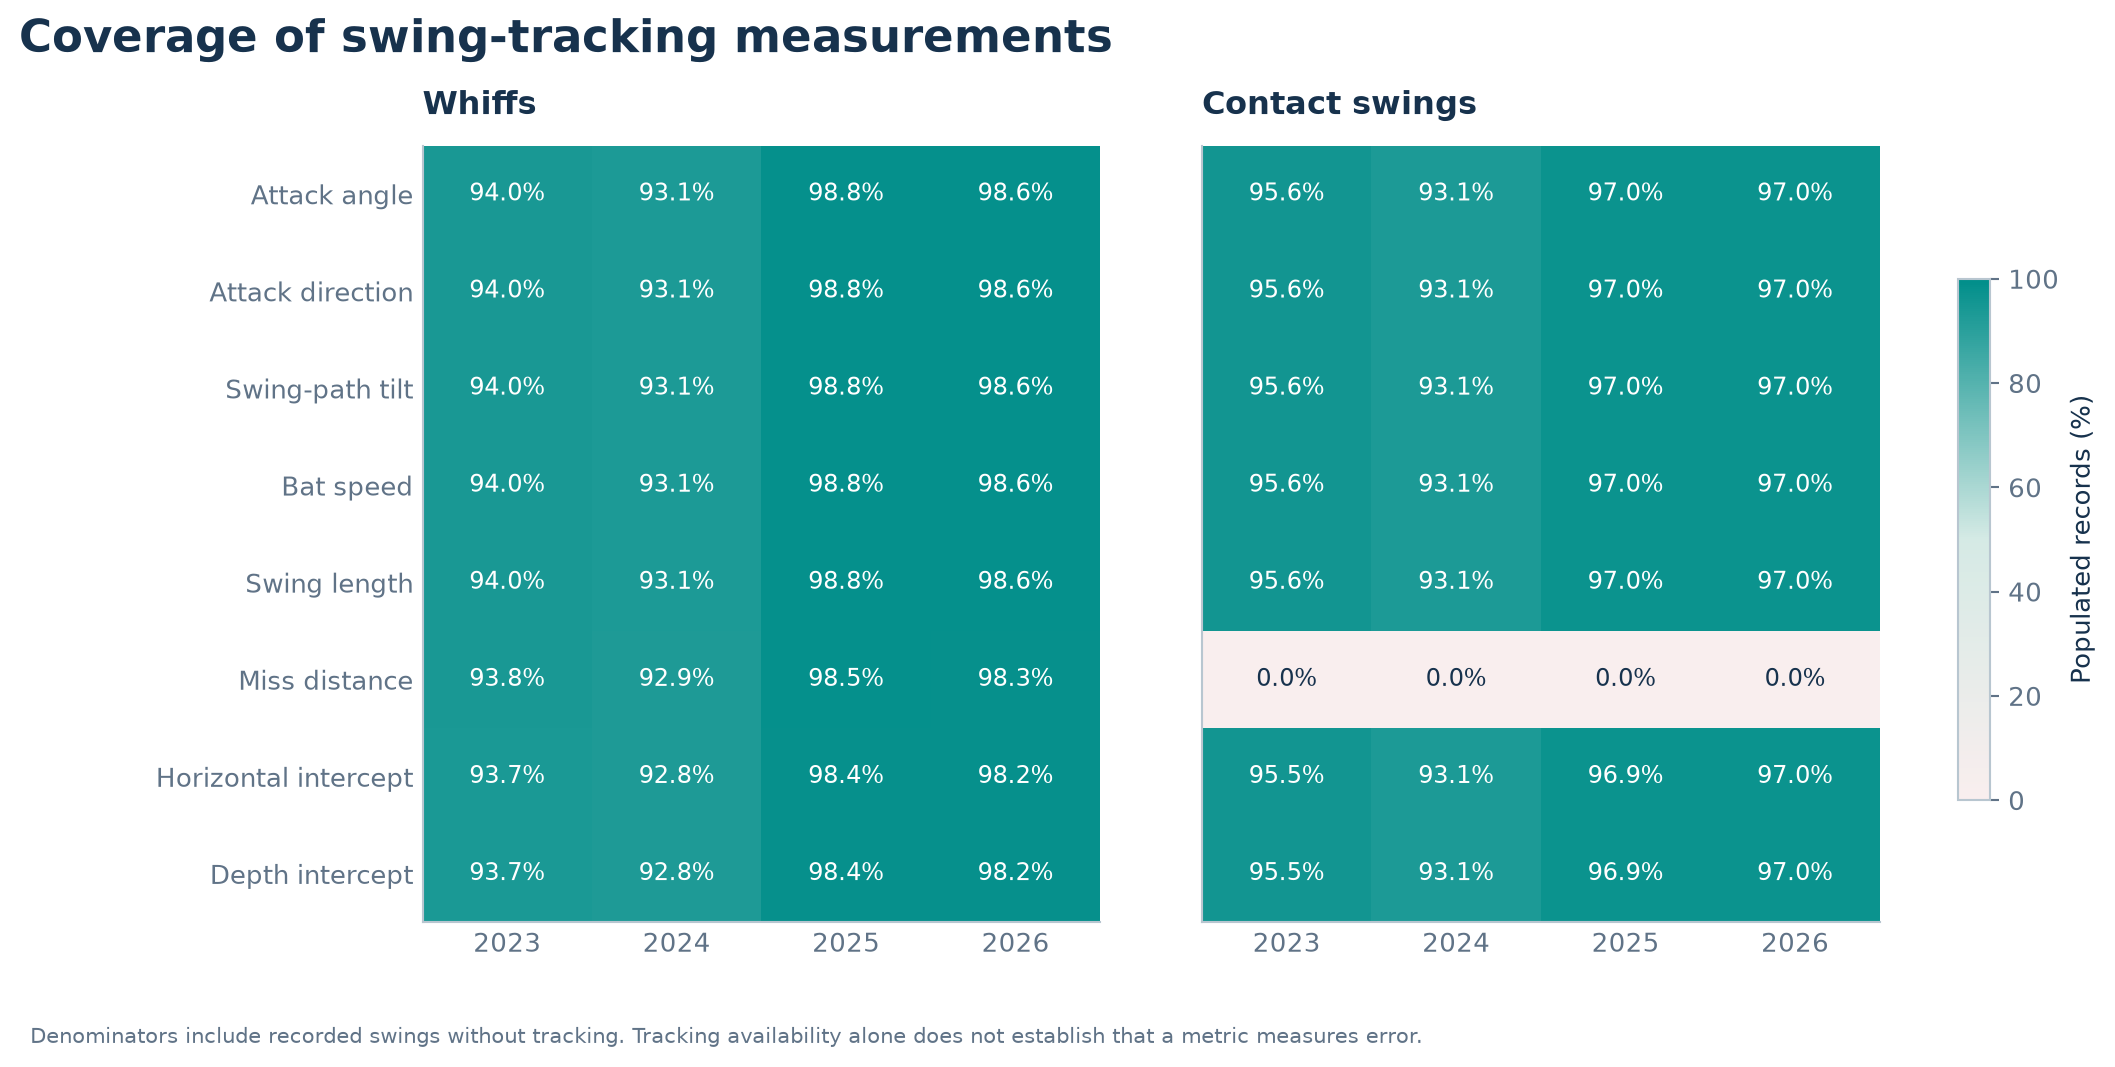

,season,field,n_whiffs,populated_whiffs,pct_whiffs
0,2023,bat_speed,36130,33964,94.0050
1,2023,swing_length,36130,33964,94.0050
2,2023,attack_angle,36130,33964,94.0050
3,2023,attack_direction,36130,33964,94.0050
4,2023,swing_path_tilt,36130,33964,94.0050
5,2023,intercept_ball_minus_batter_pos_x_inches,36130,33851,93.6922
6,2023,intercept_ball_minus_batter_pos_y_inches,36130,33851,93.6922
7,2023,miss_distance,36130,33900,93.8278


In [5]:
show_figure("02_tracking_coverage")
coverage = table("data_coverage_season.csv")
display(coverage[["group", "field", "n_whiffs", "populated_whiffs", "pct_whiffs"]]
        .rename(columns={"group": "season"}).head(8))

## 3. Pitch histories and exposure

This runnable example starts from a real raw-data partition, takes one complete game, and rebuilds pitch histories before filtering to swings. Previous-pitch features reset at the plate-appearance boundary. Repeated exposure to the same pitcher and pitch type can continue across plate appearances within the game. All counts exclude the current pitch. Automatic balls and strikes are administrative events and are excluded from the physical exposure history.

The continuous shape kernel also uses only earlier pitches. For the original analysis, its physical scales and candidate memory half-lives were fixed before examining holdout outcomes.

In [6]:
from src.features.sequences import prepare_pitches
raw_file = sorted((ROOT / "data/raw").glob("statcast_*.parquet"))[0]
raw_window = pd.read_parquet(raw_file)
game_id = raw_window.game_pk.iloc[0]
game = prepare_pitches(raw_window.loc[raw_window.game_pk.eq(game_id)].copy())
pa_sizes = game.groupby("at_bat_number").size()
pa_id = pa_sizes[pa_sizes.ge(5)].index[0] if (pa_sizes >= 5).any() else pa_sizes.idxmax()
sequence = game.loc[game.at_bat_number.eq(pa_id),
    ["game_pk", "at_bat_number", "pitch_number", "pitch_type", "description",
     "lag1_pitch_type", "exposure_pa", "exposure_pitcher", "kernel_exposure"]]
assert game.groupby(["game_pk", "at_bat_number"]).head(1).lag1_pitch_type.isna().all()
assert game.groupby(["game_pk", "batter", "pitcher", "pitch_type"]).head(1).exposure_pitcher.eq(0).all()
display(sequence)
print("Verified: PA boundaries reset history; first comparable pitch has zero prior exposures.")
del raw_window

,game_pk,at_bat_number,pitch_number,pitch_type,description,lag1_pitch_type,exposure_pa,exposure_pitcher,kernel_exposure
0,717365,1,1,FF,ball,NaN,0,0,0.0000
1,717365,1,2,FF,called_strike,FF,1,1,0.9544
2,717365,1,3,KC,foul,FF,0,0,0.0000
3,717365,1,4,SL,ball,KC,0,0,0.0004
4,717365,1,5,FF,called_strike,SL,2,2,1.4722


Verified: PA boundaries reset history; first comparable pitch has zero prior exposures.


## 4. Expected swings and deviation

Each tracked swing is compared with a baseline prediction using the current pitch, count, game context, hitter, and pitcher. The baseline does not receive previous-pitch information. Physical component residuals remain available in degrees, mph, and feet.

A separate 2024 calibration sample determines residual scales and a regularized covariance matrix. Their Mahalanobis distance becomes a multivariate deviation score, expressed in calibration standard deviations. The covariance accounts for correlations and differences in component scale. The score does not establish an optimal swing or directly measure motor error.

In [7]:
components = CONFIG["swing_components"]
cols = ["game_date", "batter", "pitch_type"]
for component in components:
    cols += [component, f"expected_{component}", f"resid_{component}"]
baseline_examples = pd.read_parquet(sorted((ROOT / "data/processed").glob("residuals_2025*.parquet"))[0], columns=cols).head(6)
component = components[0]
display(baseline_examples[["game_date", "batter", "pitch_type", component,
                           f"expected_{component}", f"resid_{component}"]])
baseline_info = document("results/models/baseline.json")
display(Markdown(f"**Baseline training swings:** {baseline_info['current_model']['training_n']:,}. "
                 f"**Covariance calibration swings:** {baseline_info['calibration_n']:,}. "
                 f"**Components:** {', '.join(components)}."))
display(table("baseline_drift.csv")[["season", "n", "mean_deviation", "sd_deviation"]])

,game_date,batter,pitch_type,attack_angle,expected_attack_angle,resid_attack_angle
0,2025-03-31,669234,SI,17.5395,12.0730,5.4665
1,2025-03-31,669234,SI,7.3439,10.2834,-2.9396
2,2025-03-31,681481,SI,13.5652,5.4415,8.1238
3,2025-03-31,682985,CH,25.4258,22.1737,3.2521
4,2025-03-31,682985,CH,-10.3830,20.3322,-30.7152
5,2025-03-31,682985,SI,-15.2255,4.7046,-19.9301


**Baseline training swings:** 150,000. **Covariance calibration swings:** 159,801. **Components:** attack_angle, attack_direction, swing_path_tilt, bat_speed, swing_length.

,season,n,mean_deviation,sd_deviation
0,2024,159801,-0.0000,1.0000
1,2025,328151,0.1397,1.0402
2,2026,316797,0.2646,1.0675


The frozen baseline can drift across seasons. The table above audits the average and spread of its deviation score; seasonal shifts can reflect context, players, or measurement changes as well as mechanics. The relationship between deviation and swing quality requires separate validation.

## 5. Sequence prediction

Two models share the same baseline training period. The second additionally receives previous-pitch features. The chart reports paired prediction-loss changes on later seasons, with game-bootstrap intervals. Improved prediction supports an association with pitch history. A causal effect on swing mechanics is not identified.

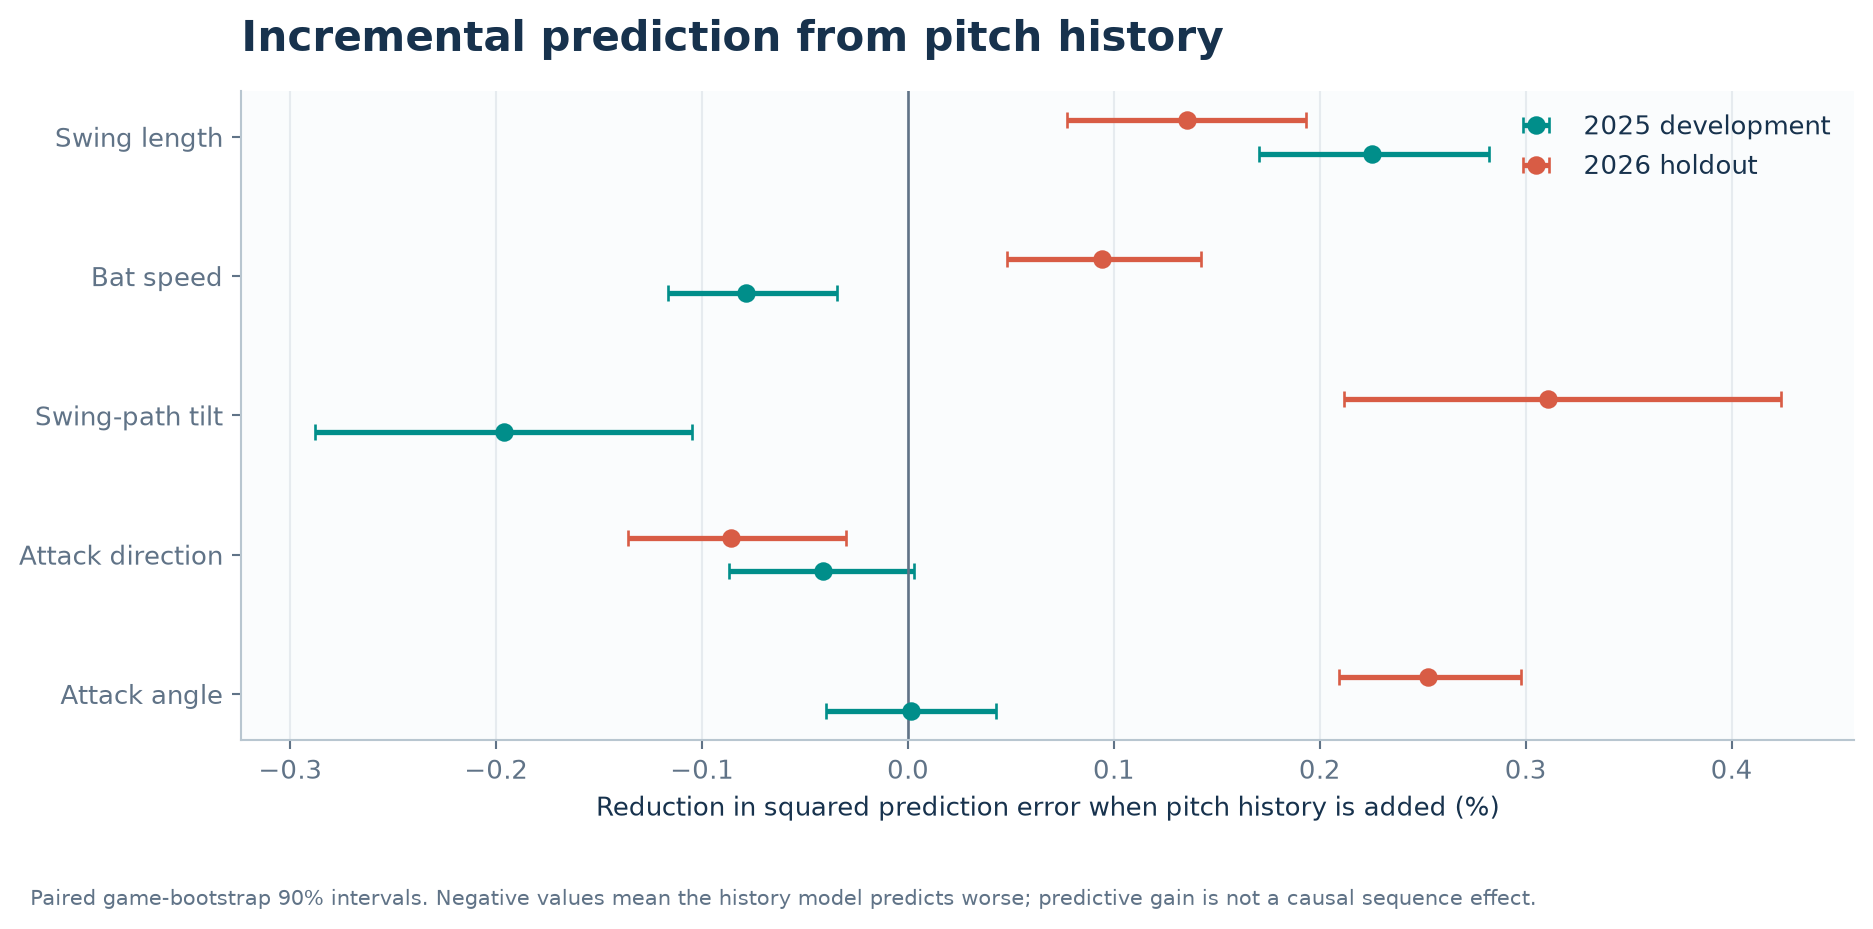

,component,n,mse_gain_pct,gain_ci90_low,gain_ci90_high
10,attack_angle,316797,0.2525,0.2091,0.2978
11,attack_direction,316797,-0.0861,-0.1362,-0.0302
12,swing_path_tilt,316797,0.3110,0.2115,0.4239
13,bat_speed,316797,0.0941,0.0480,0.1424
14,swing_length,316797,0.1356,0.0774,0.1935


In [8]:
show_figure("03_sequence_prediction_gain")
display(table("sequence_distortion.csv").query("season == 2026")
        [["component", "n", "mse_gain_pct", "gain_ci90_low", "gain_ci90_high"]])

## 6. Hierarchical exposure model

The primary exposure is the number of earlier pitches of the same type from the same pitcher in the same game. Outcome and log exposure are separately residualized using current-pitch and sequence context. Each hitter receives a conditional slope and a game-cluster robust standard error. The reported correction association is the negative slope.

The second stage treats these estimates as noisy measurements:

$$
\widehat\lambda_i\mid\lambda_i\sim N(\lambda_i,s_i^2),\qquad
\lambda_i\mid\mu,\tau\sim N(\mu,\tau^2),
$$
$$
\mu\sim N(0,0.2^2),\qquad \tau\sim\operatorname{HalfNormal}(0.15).
$$

The population mean is integrated analytically and the population spread by checked one-dimensional numerical quadrature. Independent conditional posterior draws propagate both hyperparameters. The method uses independent posterior draws; MCMC chain diagnostics such as R-hat and divergences do not apply. This remains a two-stage approximation conditional on estimated first-stage SEs; uncertainty from fitting the baseline and nuisance models is not fully propagated.

,Numerical diagnostic
grid_size,"2,401.0000"
tau_upper,0.6000
tail_mass_last_1pct,0.0000
max_mean_change_at_double_resolution,0.0000
independent_draws,"5,000.0000"
mu_mean_mcse,0.0001


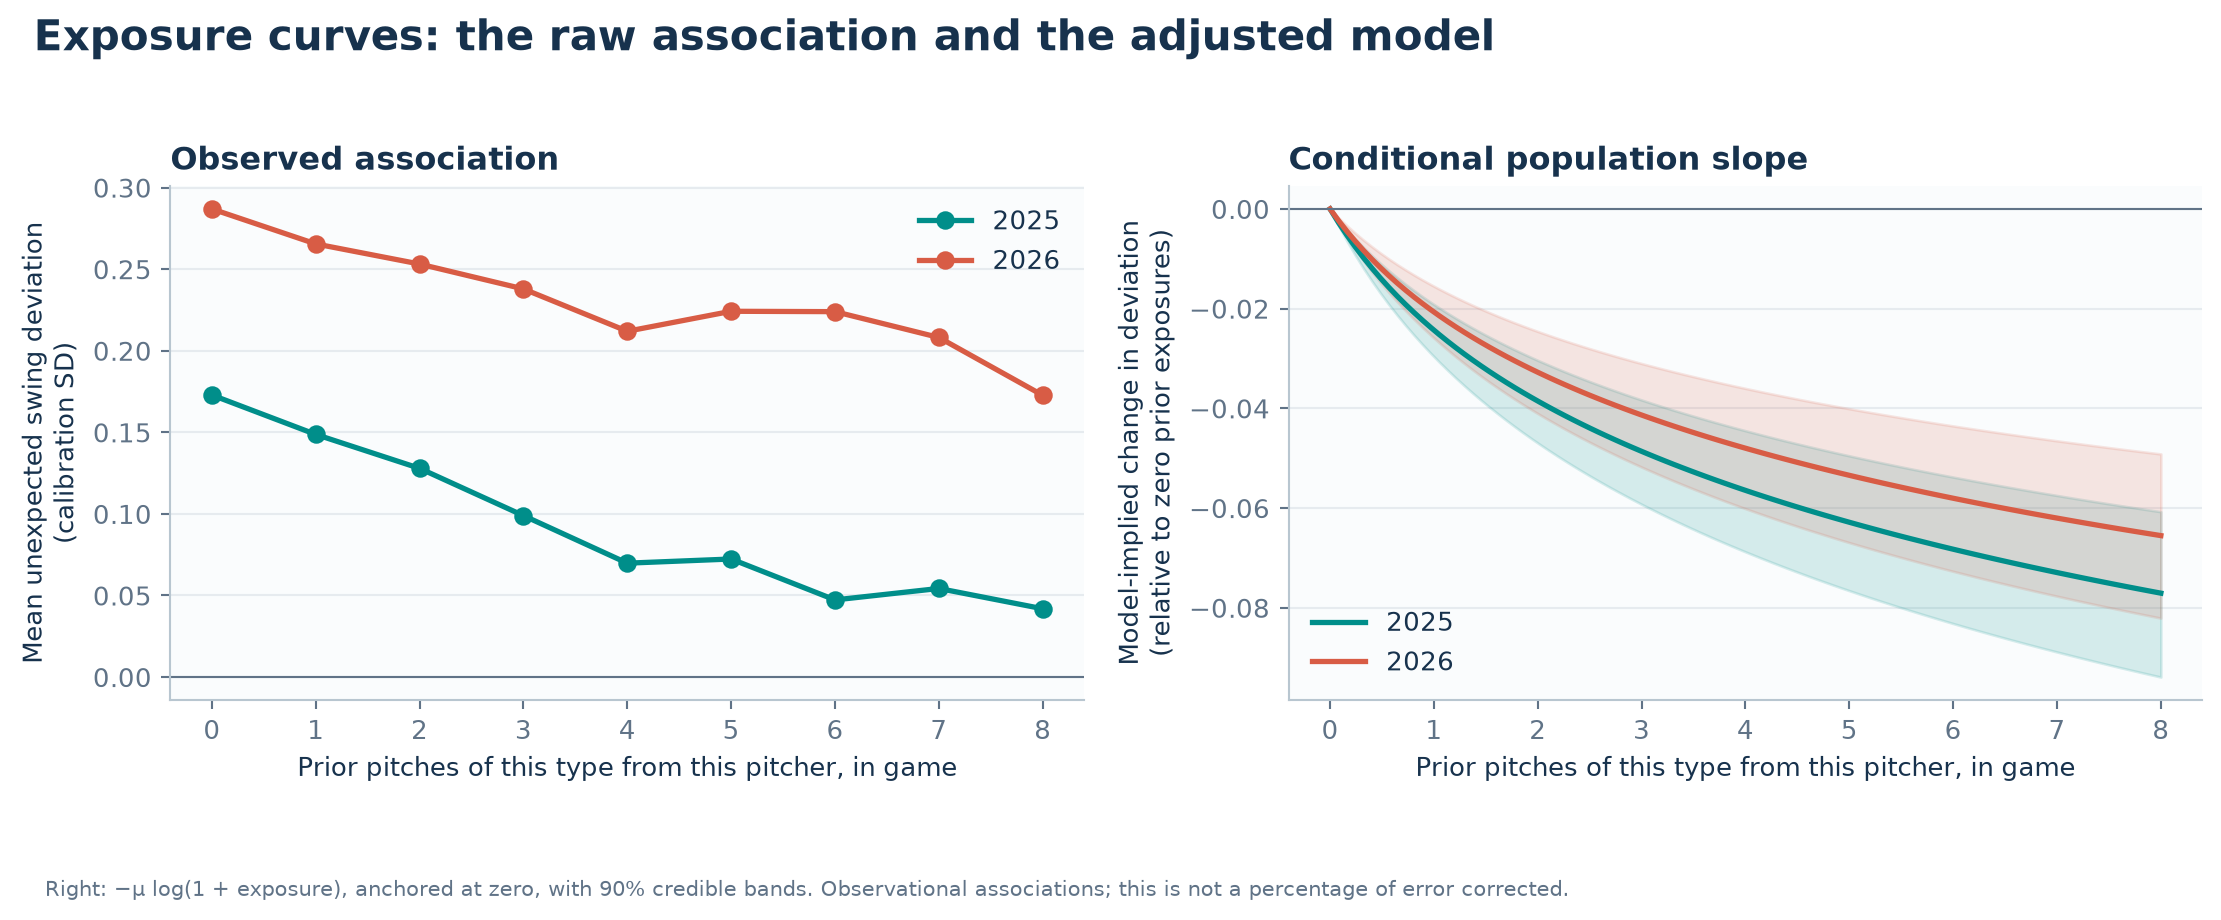

In [9]:
from src.models.hierarchical import fit_hierarchy, summarize_posterior, compare_hitters
POSTERIOR = posterior(2025)
leaderboard = table("batter_adaptation_posteriors.csv")
players_2025 = leaderboard.loc[leaderboard.season.eq(2025)].copy()
diagnostics = document("results/posterior/adaptation_2025_diagnostics.json")
display(pd.Series({key: diagnostics[key] for key in [
    "grid_size", "tau_upper", "tail_mass_last_1pct",
    "max_mean_change_at_double_resolution", "independent_draws", "mu_mean_mcse"]}, name="Numerical diagnostic").to_frame())
show_figure("04_exposure_response")

The left panel is an observed association in the analytic sample. The right panel is the model-implied conditional change, $-\mu\log(1+E)$, anchored at zero exposure. The curve describes a conditional difference from zero exposure. It does not recover an absolute mechanical trajectory. Pitcher responses, unobserved intent, and selection into later exposures can contribute to the association.

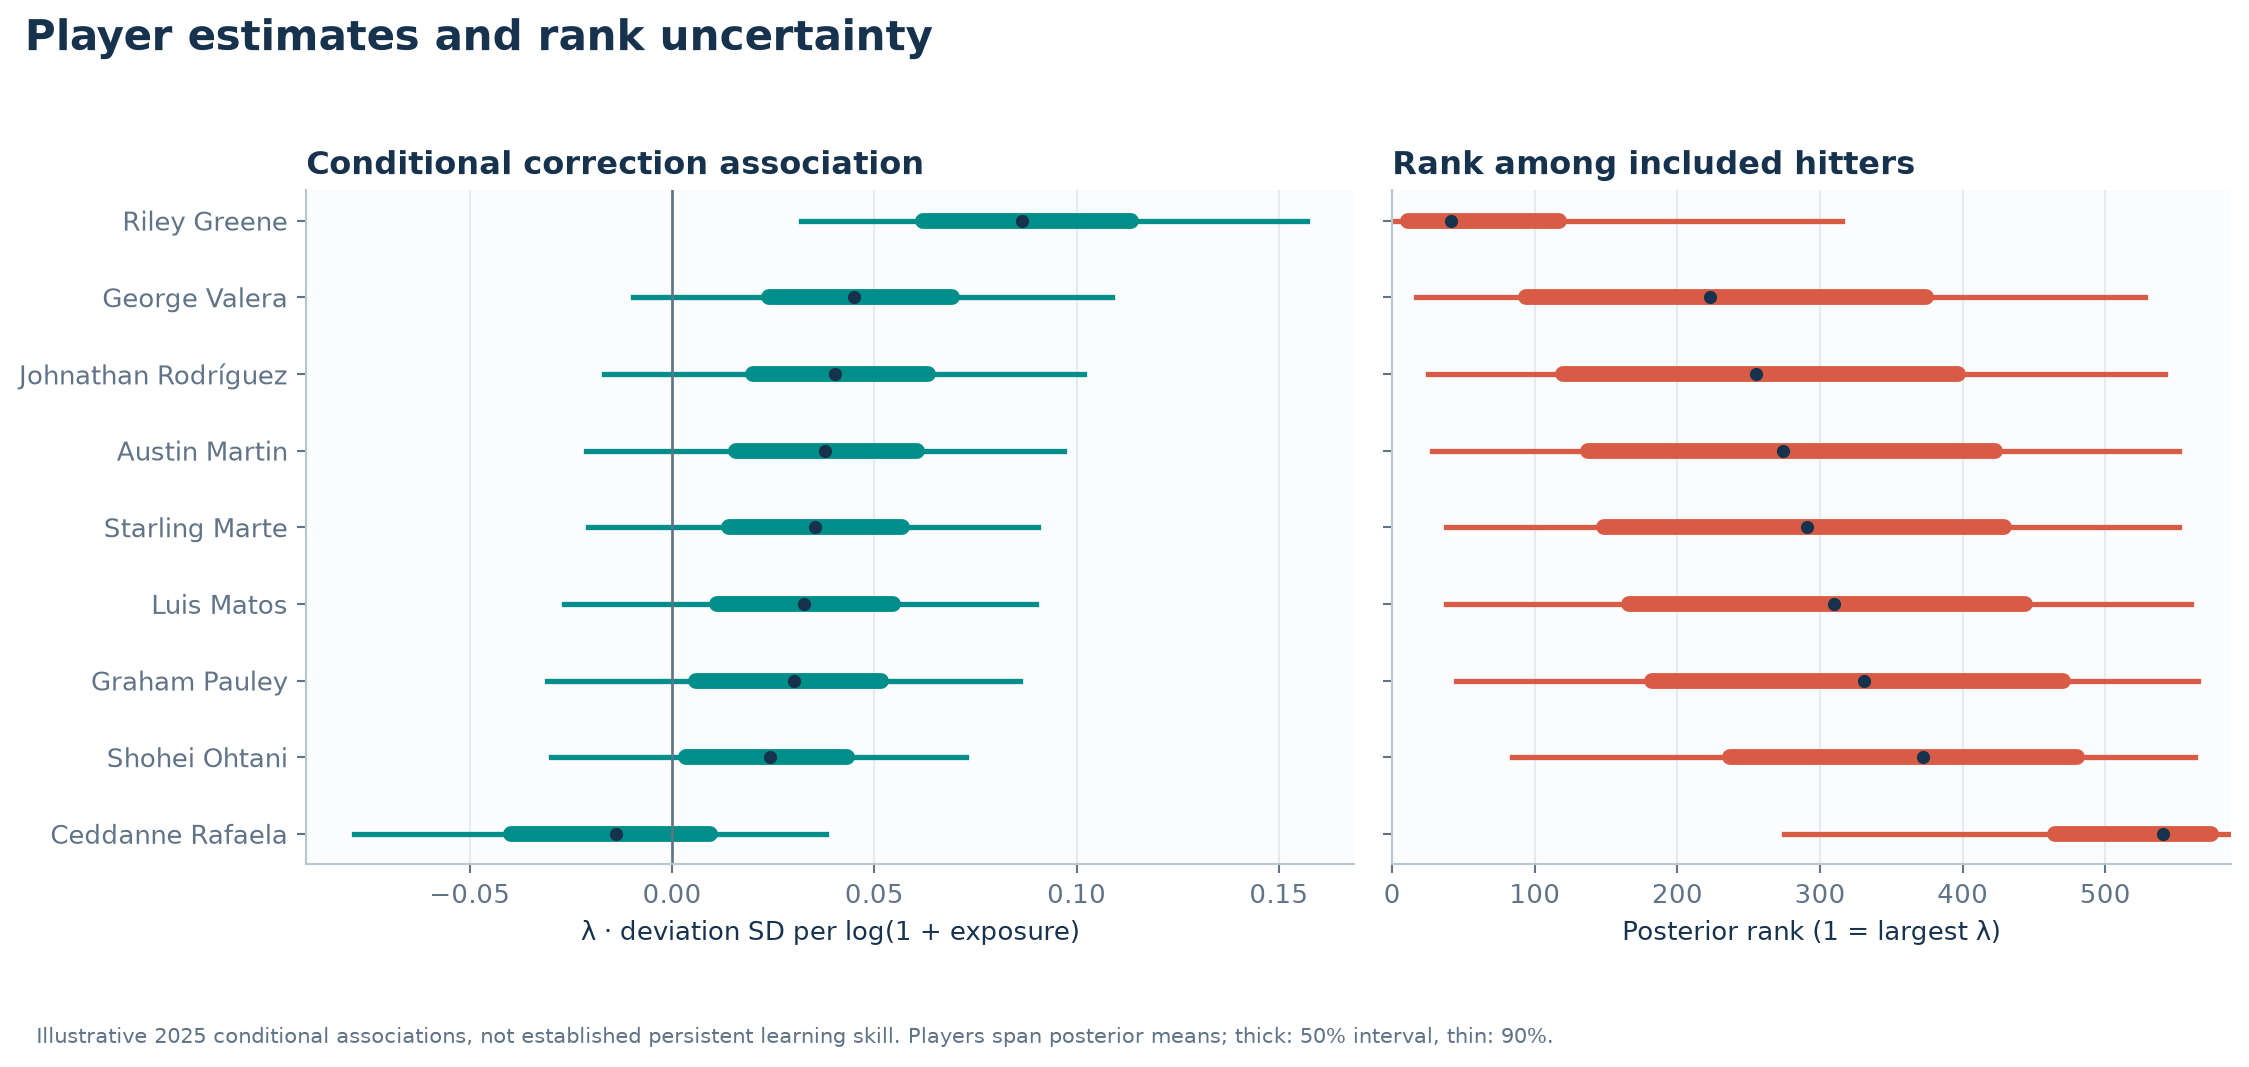

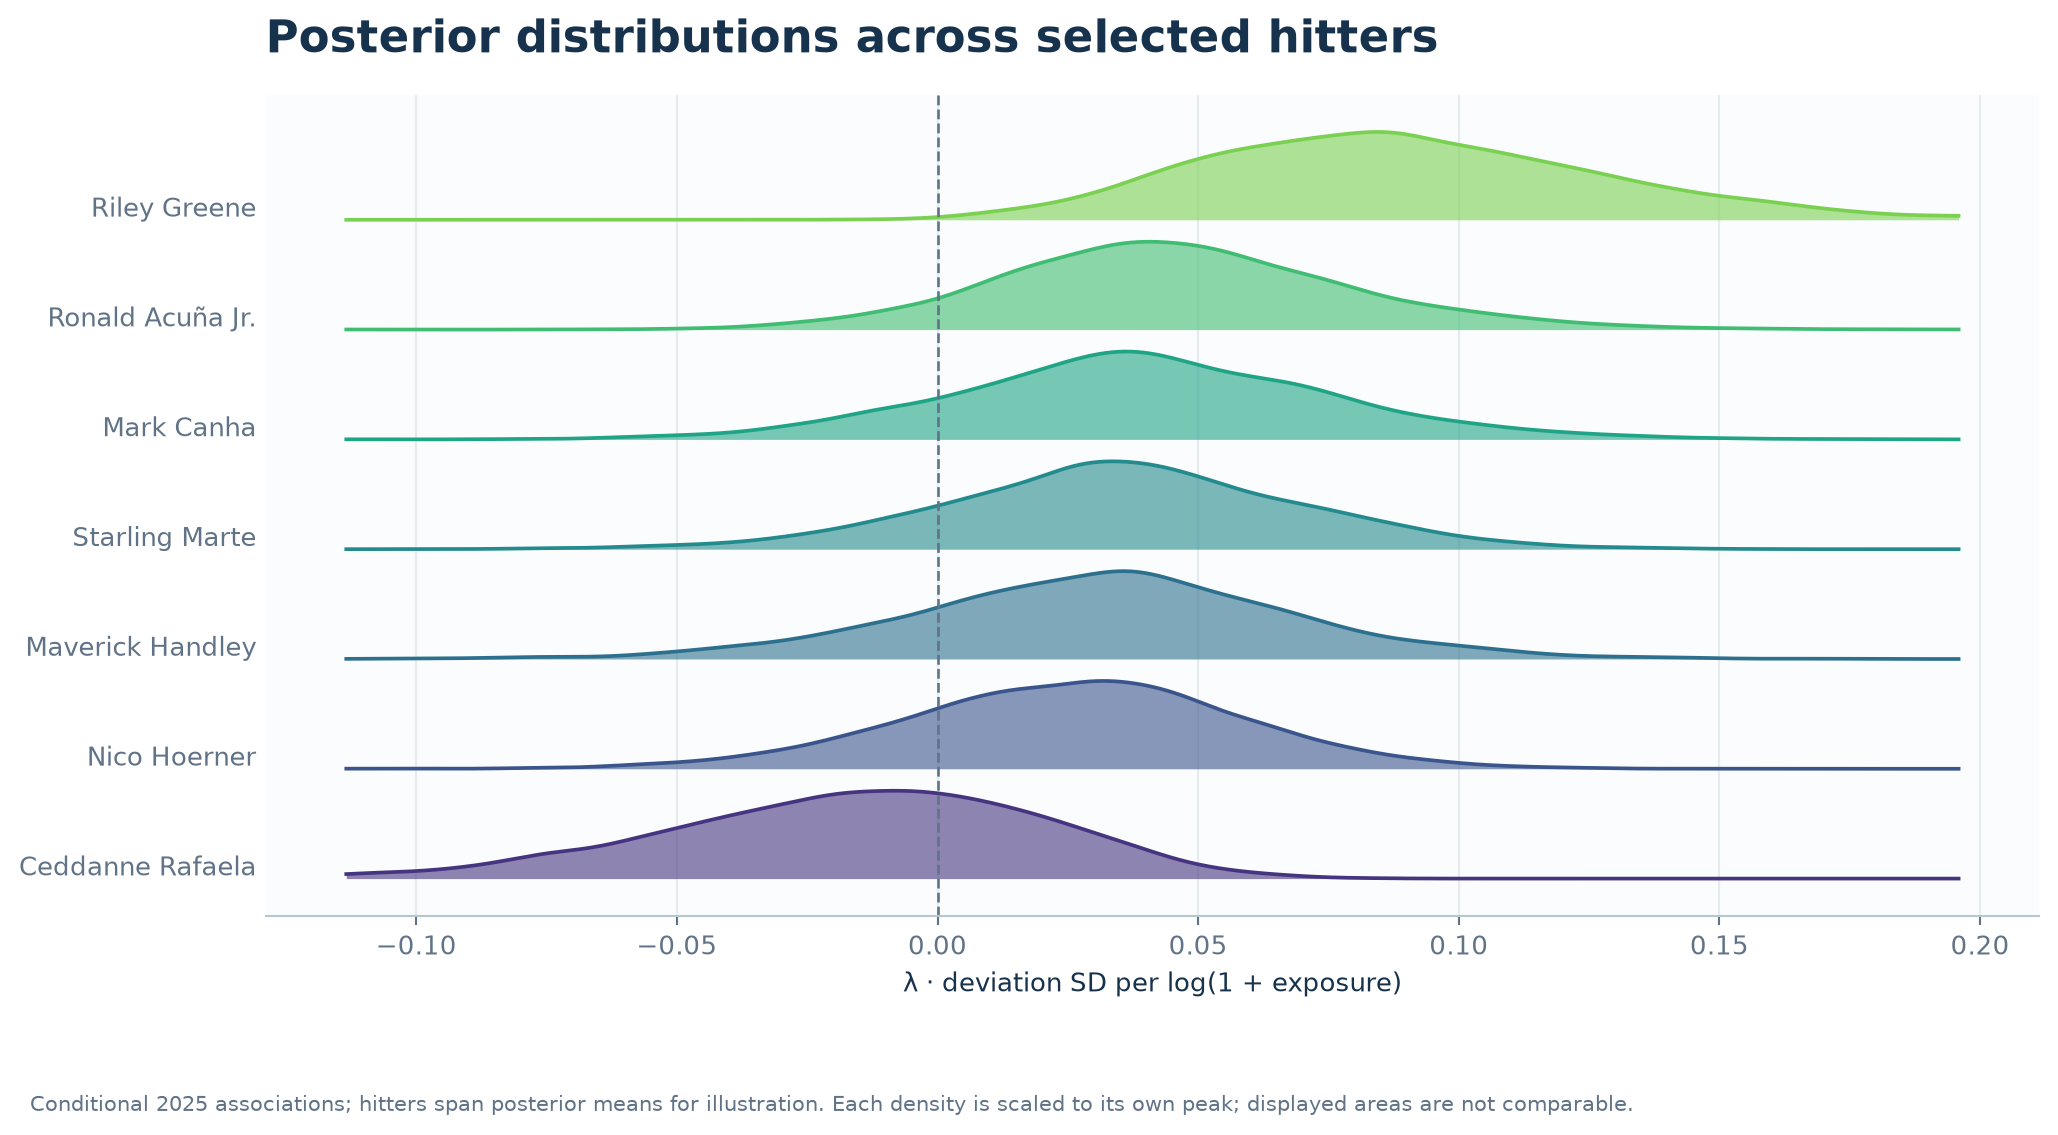

In [10]:
show_figure("05_player_and_rank_uncertainty")
show_figure("13_player_posterior_distributions")

Players shown here are sampled across posterior means to illustrate uncertainty. Their inclusion is descriptive. A posterior rank interval can span much of the eligible player pool despite differences in point estimates. “League median” in the tables means the draw-specific median of the included model population.

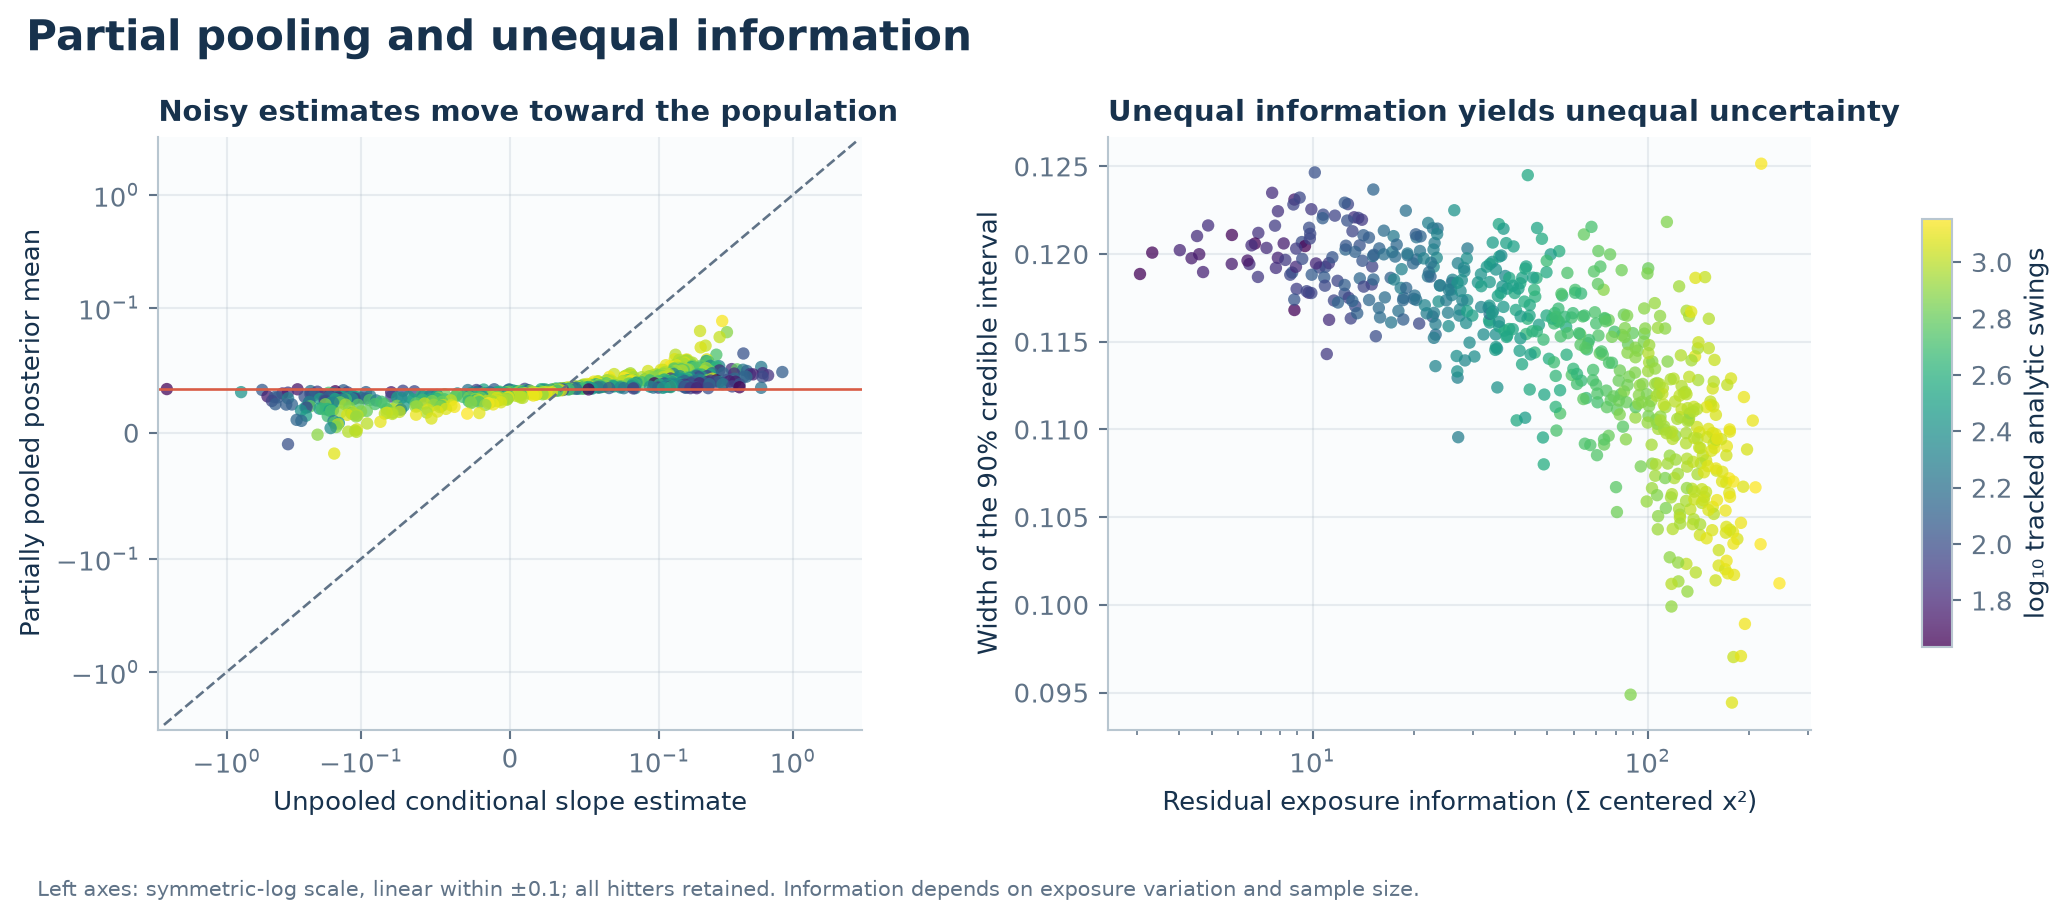

In [11]:
show_figure("07_shrinkage_and_information")

## 7. Pairwise player comparisons

Change `PLAYER_A` and `PLAYER_B` to any displayed player names. The comparison uses paired draws from the joint posterior, preserving shared population uncertainty. It returns a difference distribution, credible intervals, and the probability that A's conditional association exceeds B's.

The default names come from the eligible-player table. Optional dropdowns are provided when `ipywidgets` is installed. The comparison also runs without interactive controls.

### Aaron Judge vs. Shohei Ohtani (2025)
P(λA > λB) = **72.2%**. Median difference **0.0239**; 90% credible interval **[-0.0439, 0.1038]**. These probabilities compare conditional exposure associations. They do not establish differences in learning skill.

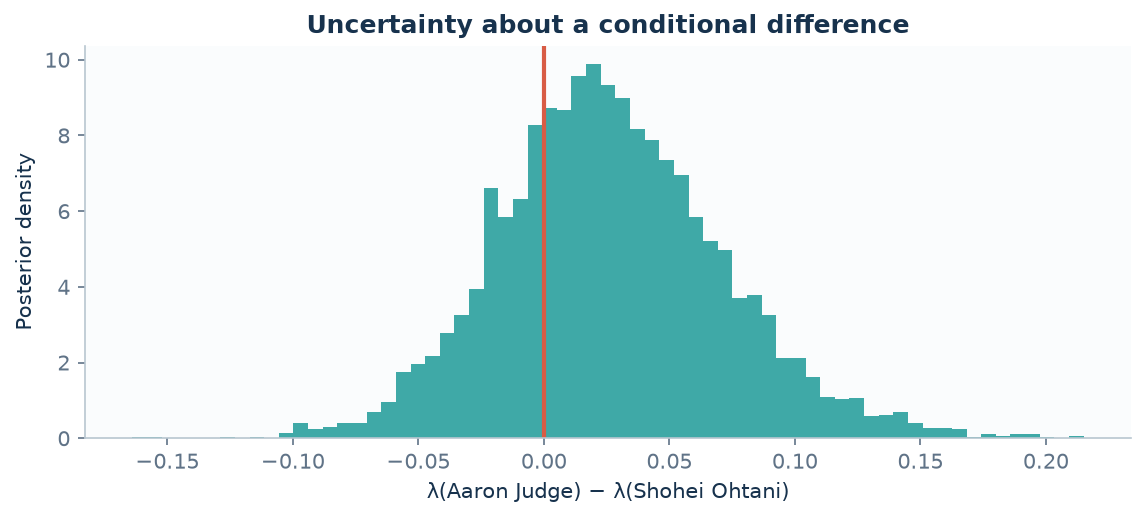

In [12]:
available_names = sorted(players_2025.player_name.astype(str).unique())
preferred_names = ["Aaron Judge", "Shohei Ohtani", "Juan Soto", "Mookie Betts",
                   "Bobby Witt Jr.", "Vladimir Guerrero Jr.", "José Ramírez", "Kyle Tucker"]
defaults = [name for name in preferred_names if name in available_names]
defaults += [name for name in available_names if name not in defaults]
PLAYER_A, PLAYER_B = defaults[:2]
name_to_id = dict(zip(players_2025.player_name, players_2025.player_id))

def compare_named_hitters(name_a, name_b, show=True):
    if name_a == name_b:
        raise ValueError("Choose two different hitters for a meaningful comparison.")
    comparison = compare_hitters(POSTERIOR, name_to_id[name_a], name_to_id[name_b])
    if show:
        probability = comparison["probability_a_greater"]
        probability_text = "<0.1%" if probability < .001 else ">99.9%" if probability > .999 else f"{probability:.1%}"
        display(Markdown(f"### {name_a} vs. {name_b} (2025)\n"
            f"P(λA > λB) = **{probability_text}**. "
            f"Median difference **{comparison['median_difference']:.4f}**; "
            f"90% credible interval **[{comparison['cri90'][0]:.4f}, {comparison['cri90'][1]:.4f}]**. "
            "These probabilities compare conditional exposure associations. They do not establish differences in learning skill."))
        fig, ax = plt.subplots(figsize=(9, 3.4))
        ax.hist(comparison["difference_draws"], bins=65, density=True, color="#008E8A", alpha=.75)
        ax.axvline(0, color="#D85C45", linewidth=2)
        ax.set(xlabel=f"λ({name_a}) − λ({name_b})", ylabel="Posterior density",
               title="Uncertainty about a conditional difference")
        ax.spines[["top", "right"]].set_visible(False)
        buffer = io.BytesIO()
        fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
        display(Image(data=buffer.getvalue()))
        plt.close(fig)
    return comparison

comparison = compare_named_hitters(PLAYER_A, PLAYER_B)

In [13]:
# Optional UI; the preceding cell remains the fully executable static fallback.
try:
    import ipywidgets as widgets
except ImportError:
    print("Optional dropdowns unavailable. Edit PLAYER_A / PLAYER_B and rerun the preceding cell.")
else:
    choice_a = widgets.Dropdown(options=available_names, value=PLAYER_A, description="Hitter A:")
    choice_b = widgets.Dropdown(options=available_names, value=PLAYER_B, description="Hitter B:")
    button = widgets.Button(description="Compare hitters", button_style="info")
    widget_output = widgets.Output()
    def update_comparison(_):
        with widget_output:
            widget_output.clear_output(wait=True)
            if choice_a.value == choice_b.value:
                print("Choose two different hitters for a meaningful comparison.")
            else:
                compare_named_hitters(choice_a.value, choice_b.value)
    button.on_click(update_comparison)
    display(widgets.HBox([choice_a, choice_b, button]), widget_output)

Output()

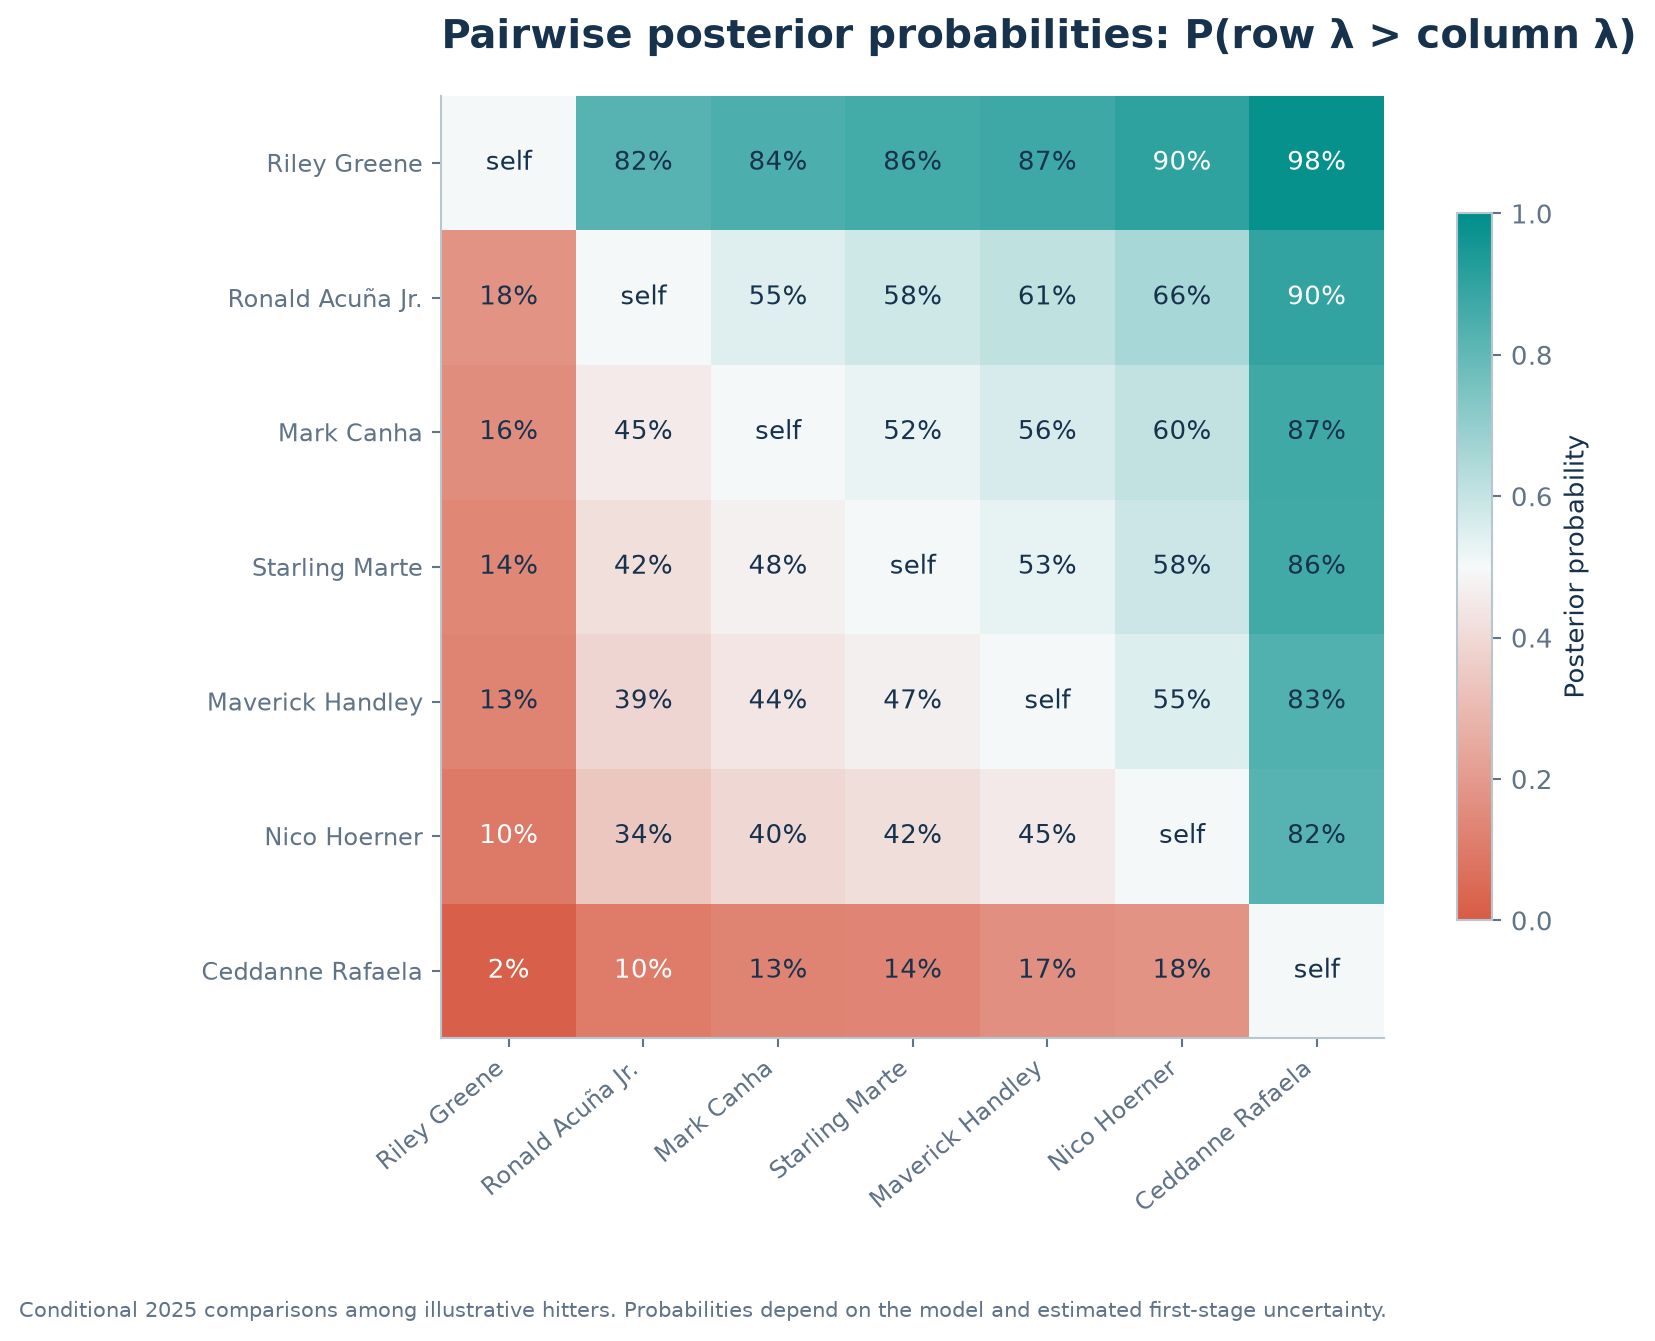

In [14]:
show_figure("06_pairwise_probability")

## 8. Parameter recovery simulations

The validation generator creates raw swing outcomes with heterogeneous player rates, unequal counts, changing pitch difficulty, within-group noise, heteroscedasticity, and missing observations. Missingness is ignorable given included covariates. The simulations do not test nonignorable tracking failures.

Groups and exposure opportunities are generated before outcome noise. First swings are sampled without selection on extreme errors, avoiding apparent improvement caused by that form of regression to the mean. Each replicate fits linear first-stage regressions with cluster-robust standard errors and the same measurement-error hierarchy. These simulations do not reproduce or validate the full flexible expected-swing and nuisance-model pipeline.

The next cell reruns a small example from scratch. Its four experiments per scenario demonstrate the code but are insufficient to establish calibration. The archived validation below uses the configured full number of independent experiments.

In [15]:
from src.evaluation.recovery import run_simulations
example_run = run_simulations(replicates=4, players=12, draws=800, seed=SEED + 99)
assert example_run["summary"]["validation_run"] is False
display(example_run["replicates"].groupby("scenario")
        [["coverage90", "rmse", "unpooled_rmse", "mean_bias"]].mean())
print("Runnable demonstration only: 4 independent experiments per scenario.")

,coverage90,rmse,unpooled_rmse,mean_bias
scenario,,,,
heterogeneous,0.8750,0.0557,0.0727,0.0068
zero_learning,0.9583,0.0270,0.0692,0.0004


Runnable demonstration only: 4 independent experiments per scenario.


,mean_coverage90,coverage90_mcse_across_experiments,mean_coverage50,mean_rmse,mean_unpooled_rmse,mean_bias,mean_mu,mean_tau,mu_excludes_zero_fraction,mu_excludes_zero_count,mean_first_stage_coverage90
heterogeneous,0.8789,0.0078,0.4911,0.0548,0.0691,0.0029,0.0577,0.0956,0.8833,53.0000,0.8744
zero_learning,0.9883,0.0039,0.7617,0.0145,0.0679,0.0002,0.0002,0.0252,0.0667,4.0000,0.8828


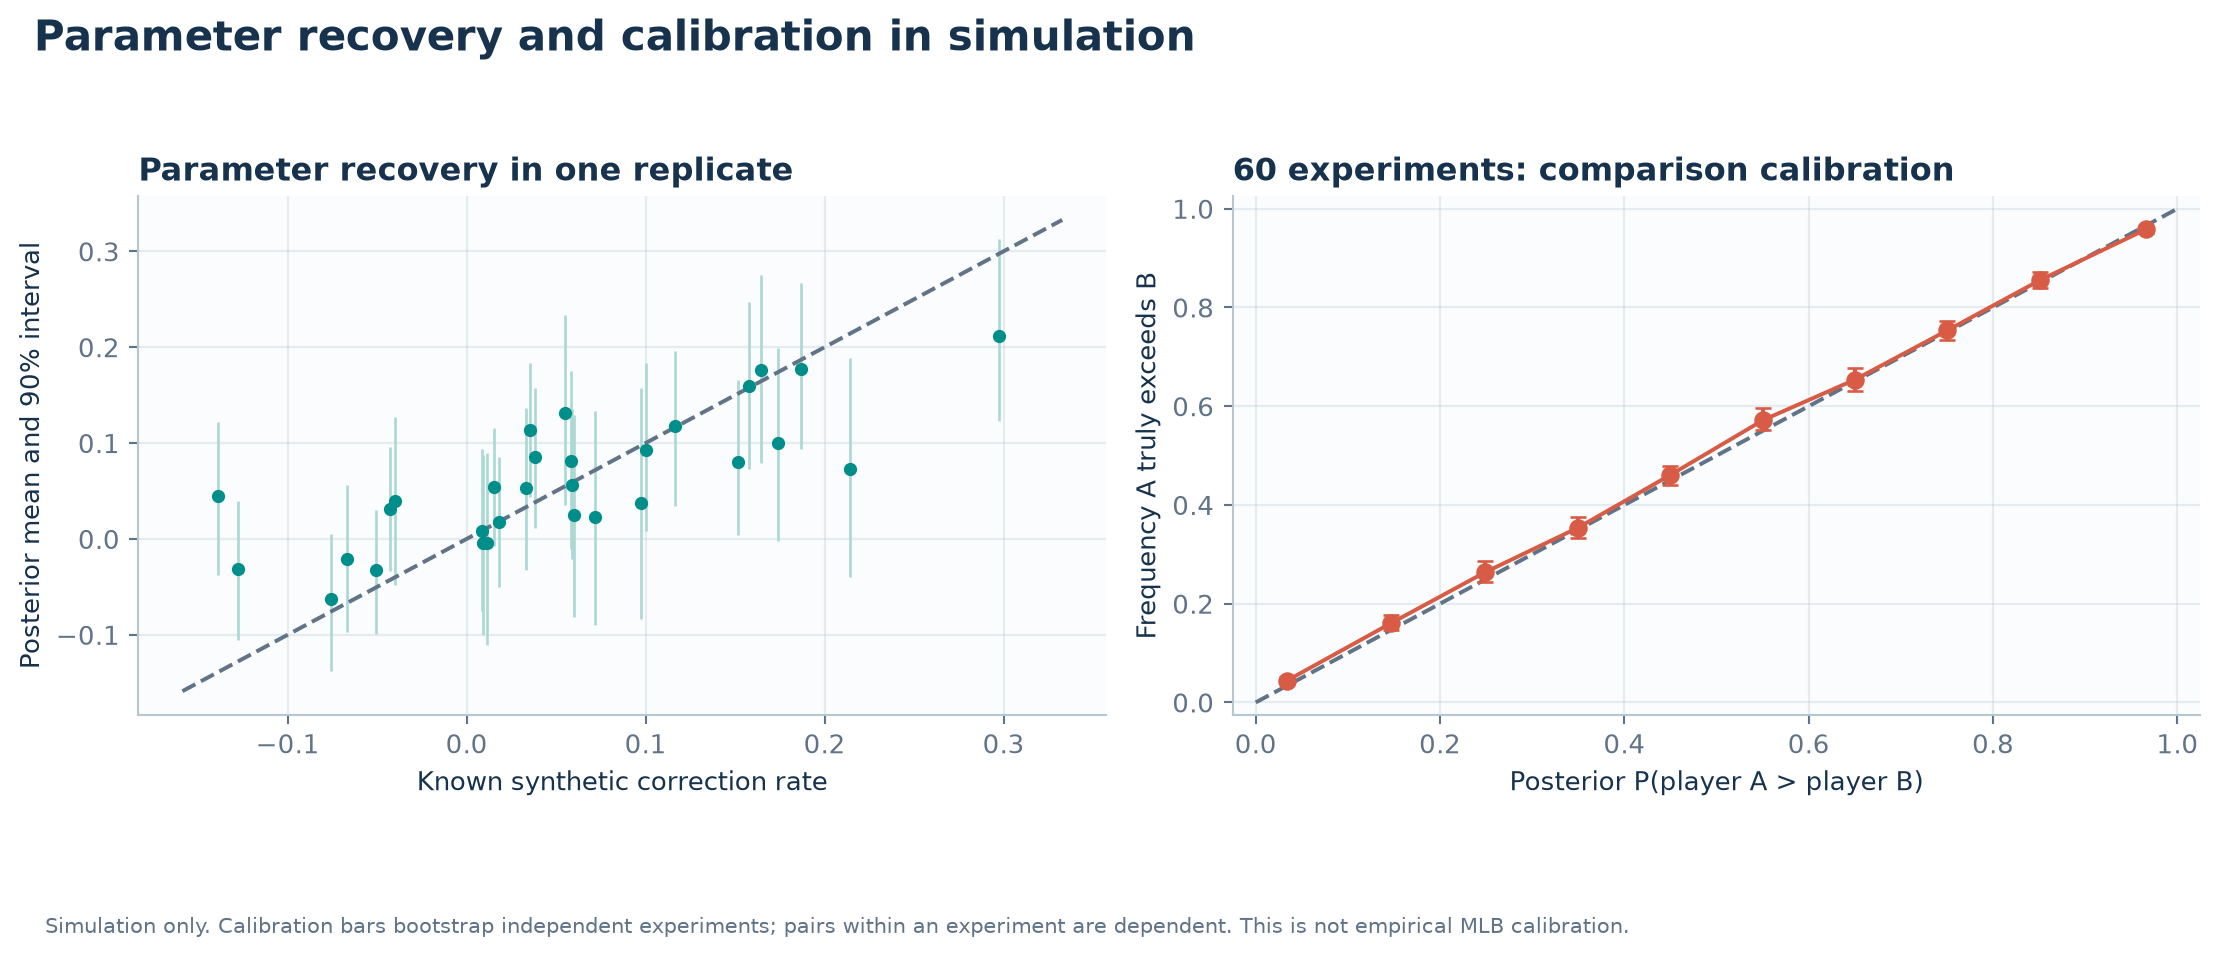

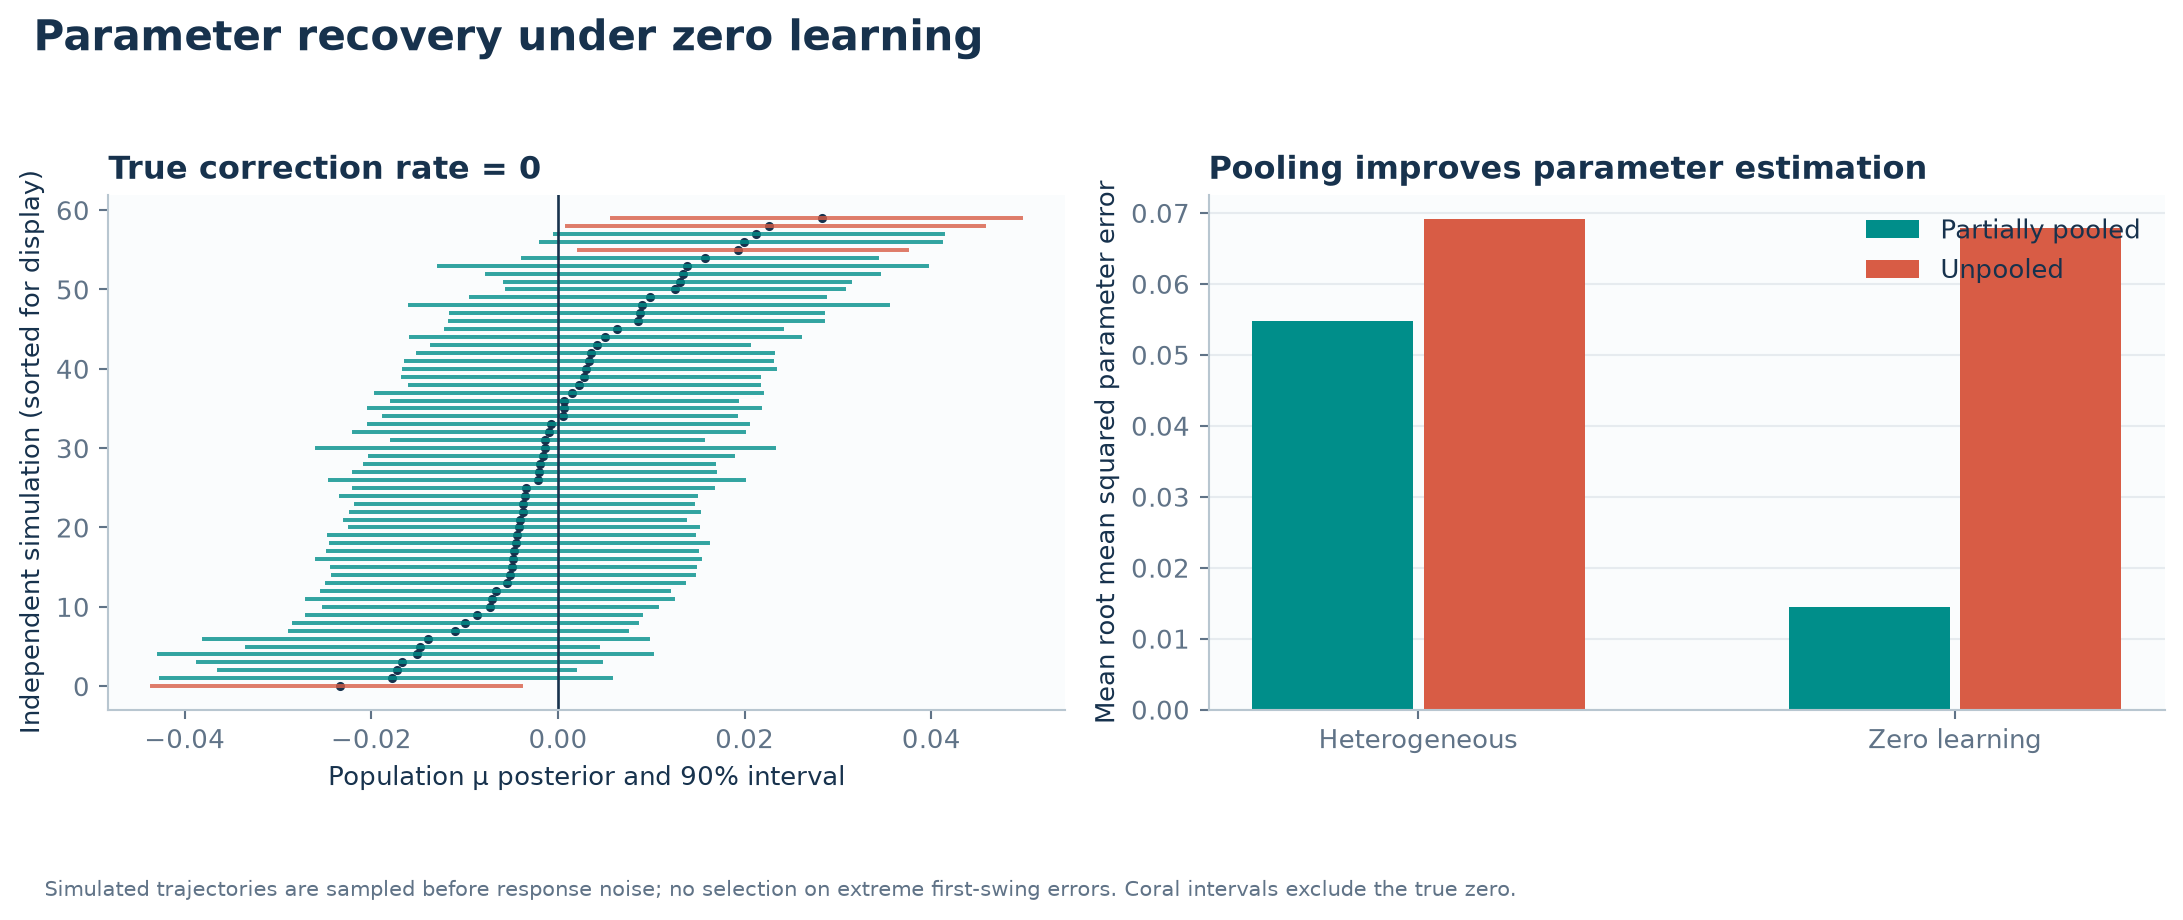

In [16]:
simulation_summary = document("results/tables/simulation_summary.json")
display(pd.DataFrame({scenario: simulation_summary[scenario]
                     for scenario in ["heterogeneous", "zero_learning"]}).T)
show_figure("08_simulation_recovery_calibration")
show_figure("09_zero_learning_guardrail")

Nominal 90% intervals need not achieve exactly 90% coverage. The archived results report observed coverage, its Monte Carlo error across independent experiments, and any overconfidence. Pairwise reliability is measured against **known synthetic truth**, with uncertainty obtained by resampling independent experiments. This evaluates synthetic comparisons. It does not establish calibration of MLB comparisons against later-season truth.

## 9. Sensitivity analyses and negative controls

Sensitivity analyses use within-PA, within-game, similar-shape, and transition exposures; component-specific deviations; sample restrictions; and alternative priors.

Shuffled residual exposure, future exposure, and exposure to other pitch types serve as negative controls. Future pitch counts can correlate with game progression and selection even though they cannot cause earlier adjustments. A similar result for these controls would weaken the adaptation interpretation.

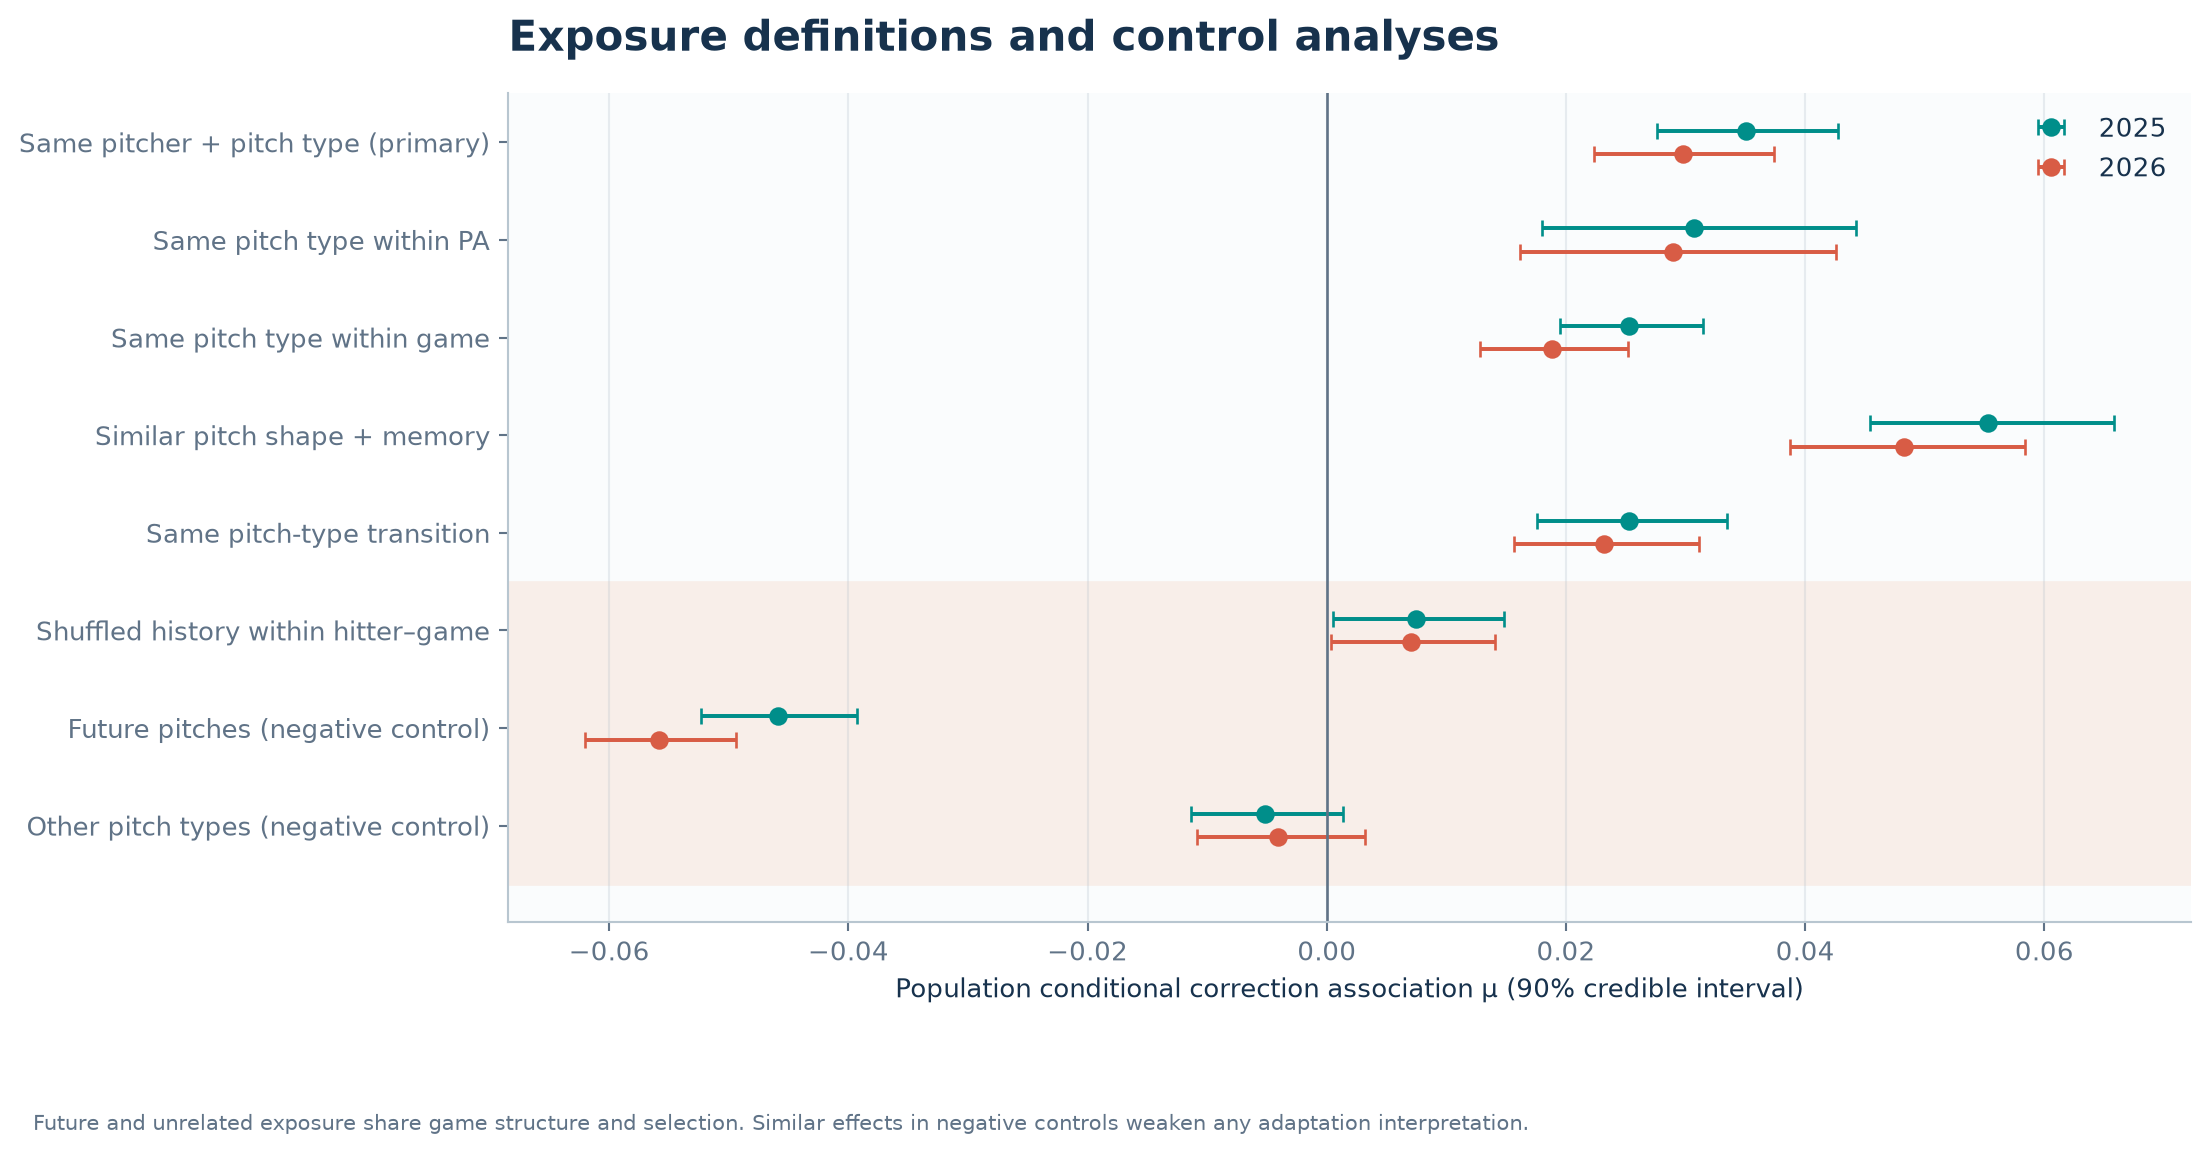

,specification,players,mu_median,mu_low,mu_high,p_mu_positive
26,exposure_pitcher,591,0.0298,0.0224,0.0374,1.0000
31,future_exposure,591,-0.0559,-0.0620,-0.0494,0.0000
32,irrelevant_exposure,591,-0.0040,-0.0108,0.0032,0.1753
45,shuffled_within_batter_game,591,0.0070,0.0004,0.0141,0.9603


In [17]:
show_figure("10_robustness_negative_controls")
robustness = table("robustness.csv")
display(robustness.loc[robustness.season.eq(2026) & robustness.specification.isin([
    "exposure_pitcher", "shuffled_within_batter_game", "future_exposure", "irrelevant_exposure"]),
    ["specification", "players", "mu_median", "mu_low", "mu_high", "p_mu_positive"]])

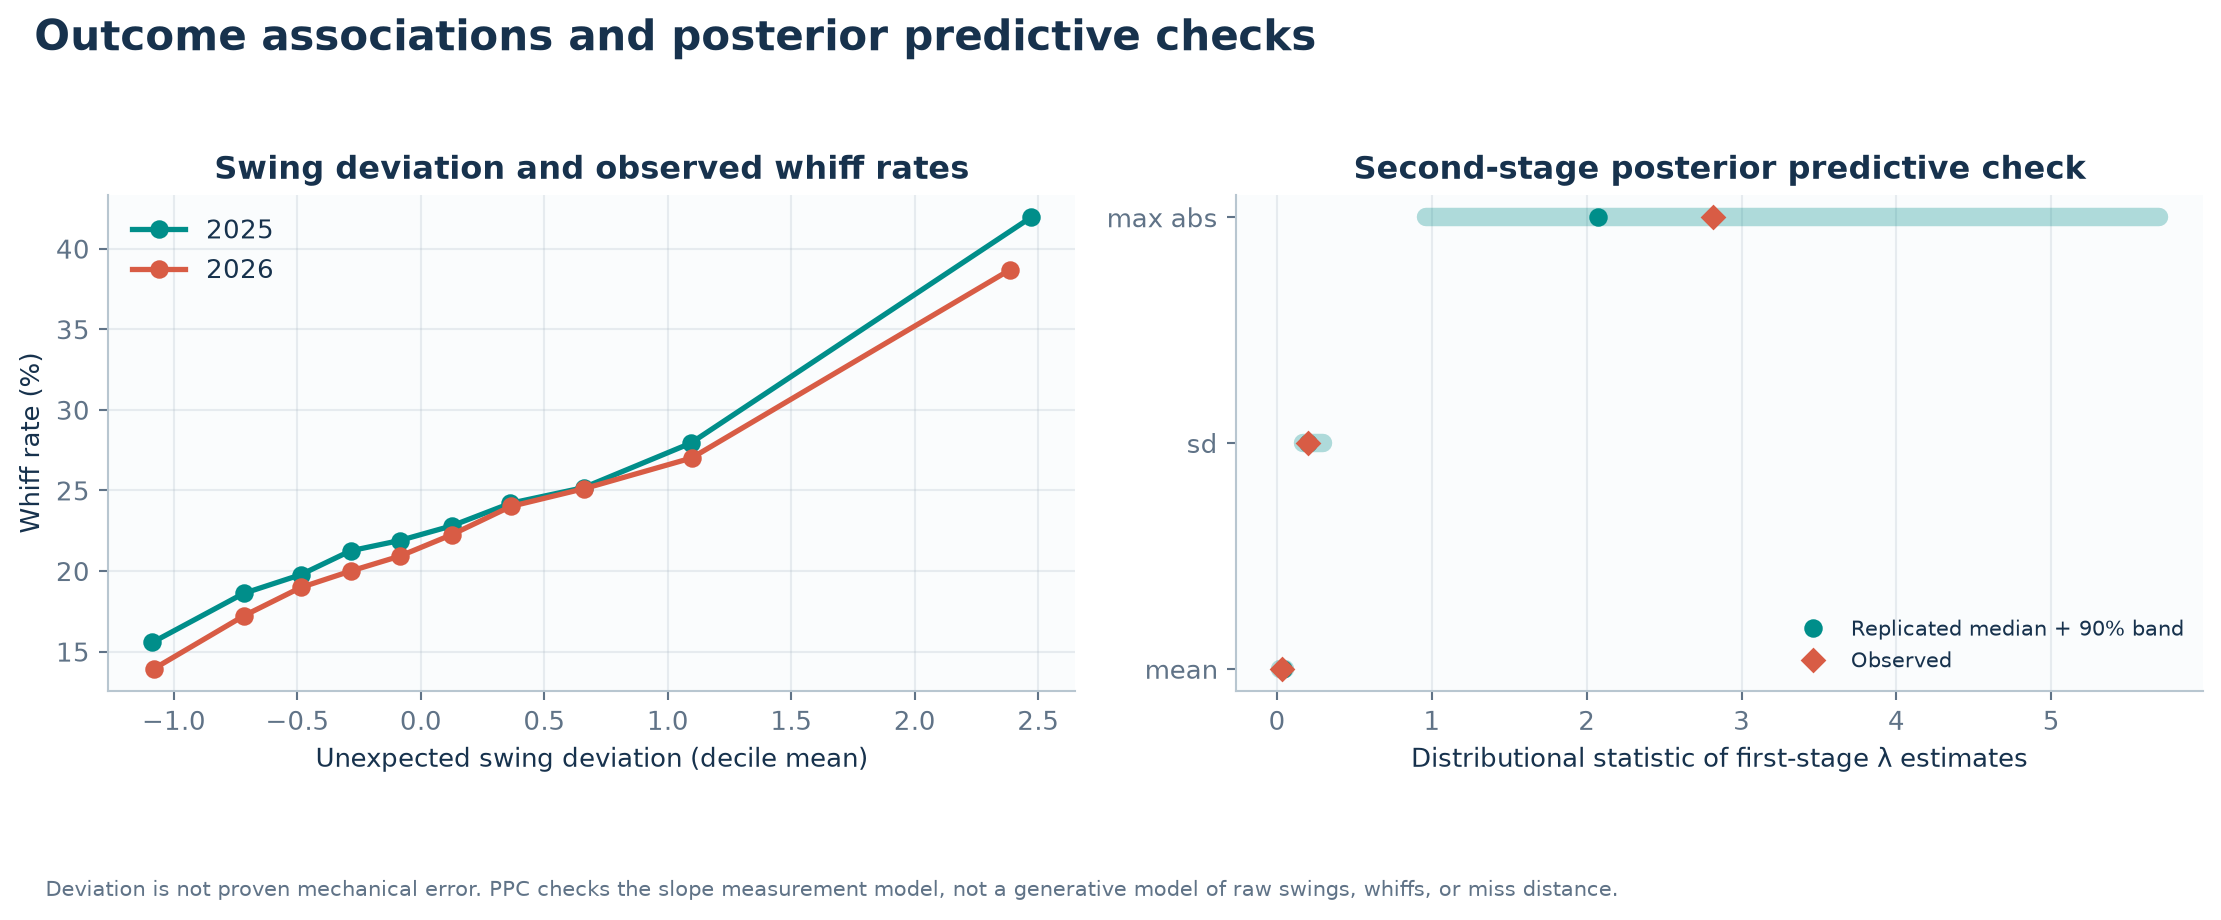

In [18]:
show_figure("12_outcome_link_and_predictive_check")

The outcome plot checks whether the deviation proxy is related to whiffs. An association with whiffs does not establish that all deviations are mechanical errors. The posterior predictive check targets the **first-stage slope estimates**, because that is the outcome of the Bayesian measurement model. Raw-swing, whiff, and miss-distance generative checks would require additional generative models.

### Outcome validation and sample selection

A classifier trained on 2025 predicts 2026 whiffs from current-pitch context, then adds observed swing-component deviations. This measures held-out discrimination using contemporaneous mechanics. The required measurements are observed during the swing, so it cannot serve as a pre-pitch whiff forecast.

Miss distance provides a bat-ball proximity endpoint observed only on a selected subset of tracked whiffs. **Distances for contacts remain missing.** Its log transform is standardized using 2025 whiffs; the resulting conditional exposure slope cannot establish unconditional error learning. The inclusion audit separately shows how tracking, sanity bounds, and shape availability vary across exposure opportunities.

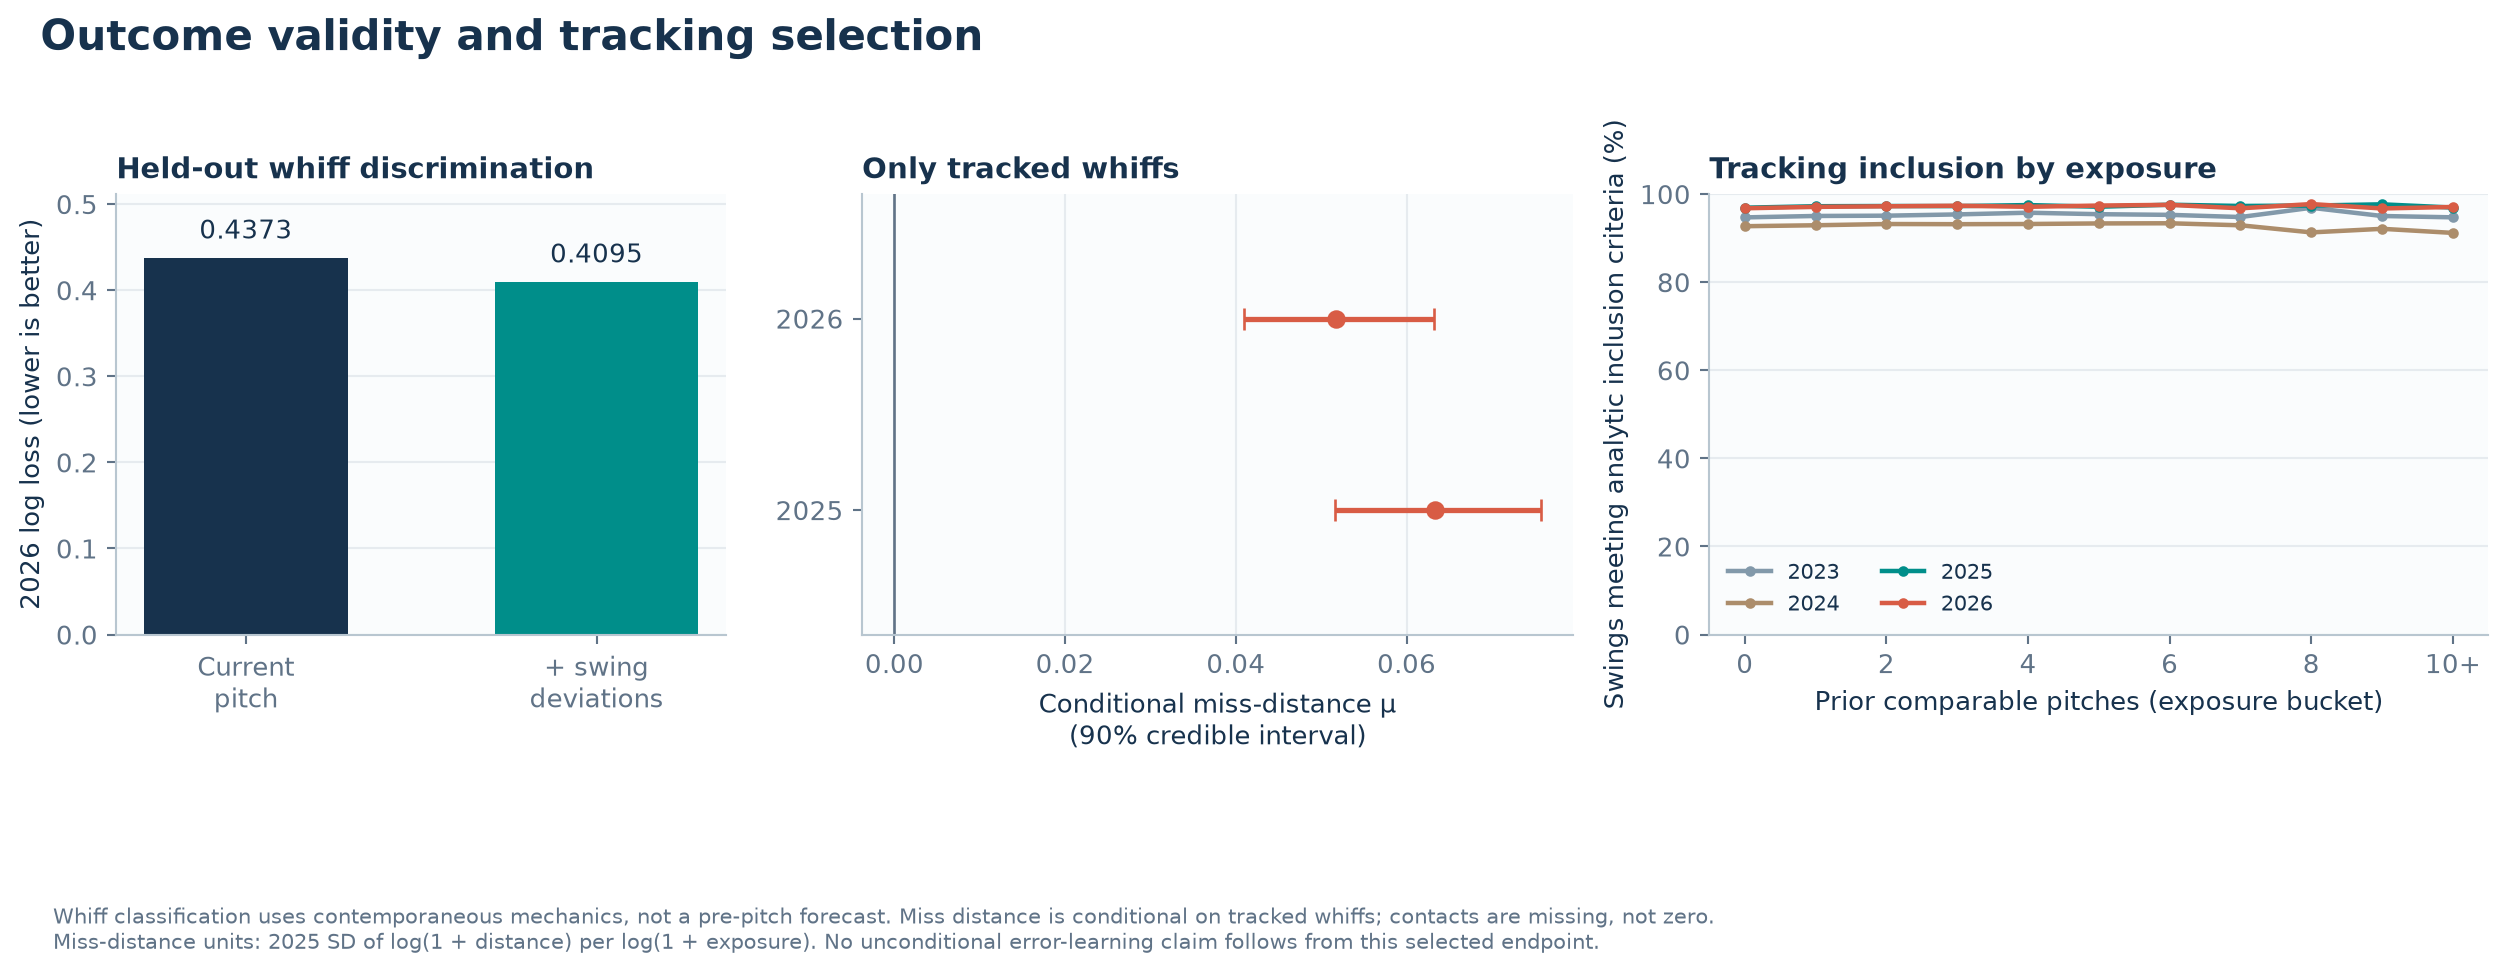

,model,test_season,test_n,log_loss,auc
0,current_pitch,2026,316713,0.4373,0.7813
1,plus_swing_deviations,2026,316713,0.4095,0.8171


In [19]:
show_figure("15_outcome_sensitivity_and_selection")
display(table("whiff_validation.csv")[["model", "test_season", "test_n", "log_loss", "auc"]])

### Matched-pitch comparisons

This supplementary restriction matches within hitter, game, pitcher, pitch type, and exact count. Speed, movement, front-plane location and release point must satisfy fixed physical tolerances. Each swing is used at most once; outcomes and their missingness never choose a match. The full pairing audit is included in the frozen data.

Negative later-minus-earlier changes mean declining deviation. These pair-weighted changes have a different estimand from the player hierarchy, and the selected matched opportunities do not represent all swings. Game-bootstrap intervals condition on the fitted models. See [matching rules and limitations](../paper/matched_comparisons.md).

In [20]:
matched = table("matched_exposure_summary.csv")
display(matched[["season", "outcome", "n_pairs", "games", "players",
    "mean_change_later_minus_earlier", "ci90_low", "ci90_high"]])
display(table("matched_exposure_balance.csv")[["season", "covariate",
    "mean_absolute_difference", "max_absolute_difference", "unit"]])

,season,outcome,n_pairs,games,players,mean_change_later_minus_earlier,ci90_low,ci90_high
0,2025,distortion,752,639,366,-0.0470,-0.1058,0.0123
1,2025,adj_distortion,752,639,366,-0.0394,-0.0981,0.0200
2,2026,distortion,668,565,353,-0.0779,-0.1429,-0.0109
3,2026,adj_distortion,668,565,353,-0.0734,-0.1387,-0.0065


,season,covariate,mean_absolute_difference,max_absolute_difference,unit
0,2025,release_speed,0.6677,2.0000,mph
1,2025,pfx_x,0.0728,0.1500,ft
2,2025,pfx_z,0.0700,0.1500,ft
3,2025,plate_x_front,0.1442,0.3465,ft
4,2025,plate_z_front,0.1496,0.3483,ft
5,2025,release_pos_x,0.0805,0.2400,ft
6,2025,release_pos_z,0.0555,0.2200,ft
7,2026,release_speed,0.7081,2.0000,mph
8,2026,pfx_x,0.0695,0.1500,ft
9,2026,pfx_z,0.0704,0.1500,ft


## 10. Temporal persistence

Persistence is tested in a joint latent-normal model that treats estimated first-stage SEs as known. Its player bootstrap can reveal wide uncertainty or boundary behavior when true between-player variation is weak. An ordinary correlation of noisy point estimates does not account for estimation error. The reported bootstrap percentiles are descriptive and need not have nominal coverage near variance or correlation boundaries. A false boundary or weak-identification flag does not establish precise estimation.

A separate holdout test asks whether 2025 player-specific slopes improve 2026 centered residual loss over the population slope. This tests conditional slope transport. It does not evaluate prospective forecasts of uncentered raw swings or future OPS or wOBA.

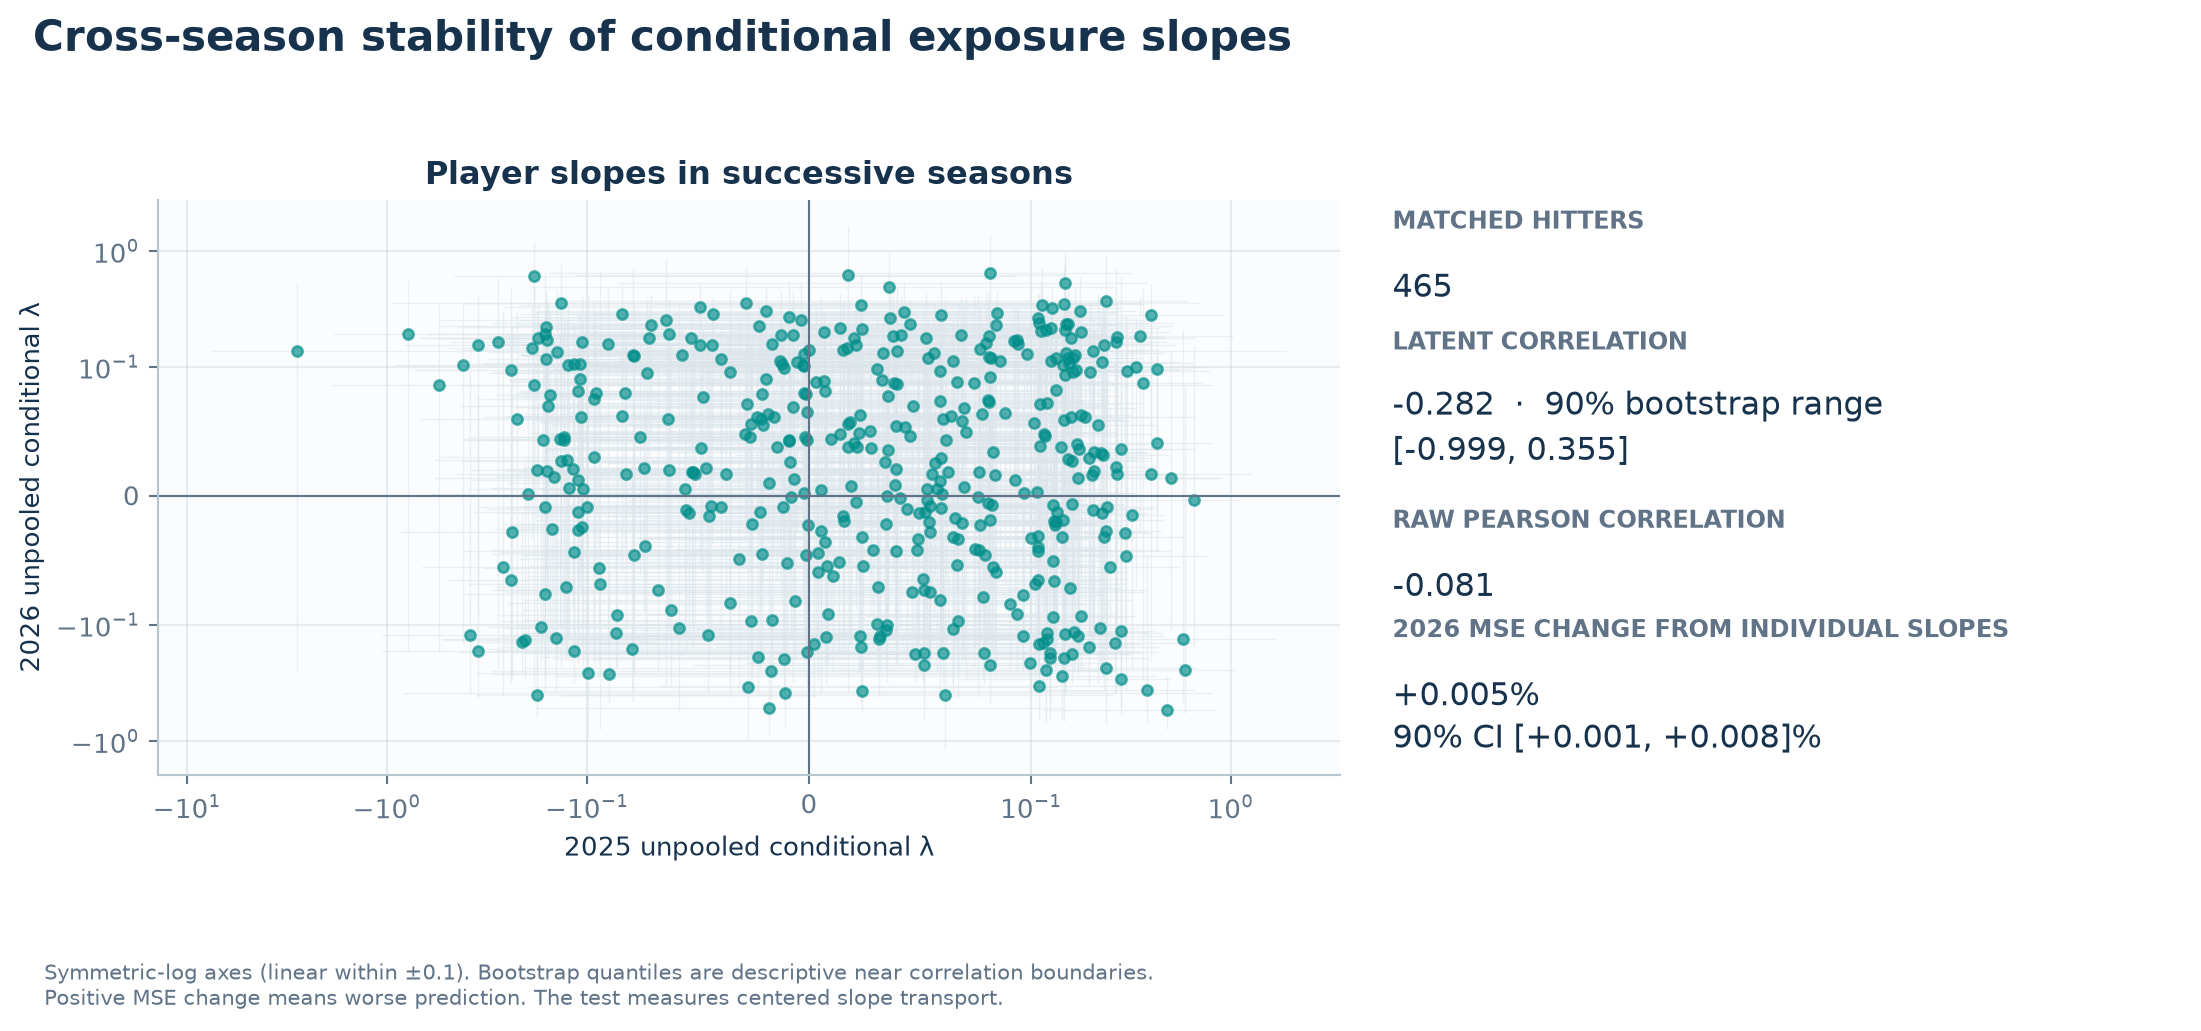

,Temporal validation
Shared hitters,465
Latent correlation,-0.2815
90% correlation interval,"[-0.9989995977858408, 0.35453293074803083]"
Boundary fit,False
Bootstrap fits with |correlation| > 0.98,14
2026 loss improvement (%),-0.0047
90% loss-improvement interval,"[-0.008117551855029057, -0.0011492214065688476]"


In [21]:
show_figure("11_temporal_persistence")
persistence = document("results/tables/persistence.json")
holdout = document("results/tables/holdout_prediction.json")
display(pd.Series({
    "Shared hitters": persistence["n_players"],
    "Latent correlation": persistence["latent_correlation"],
    "90% correlation interval": persistence["bootstrap_ci90"],
    "Boundary fit": persistence["boundary_fit"],
    "Bootstrap fits with |correlation| > 0.98": persistence["bootstrap_diagnostics"]["abs_rho_above_0_98_count"],
    "2026 loss improvement (%)": holdout["mse_improvement_pct"],
    "90% loss-improvement interval": holdout["ci90"],
}, name="Temporal validation").to_frame())

### Pairwise agreement across seasons

This diagnostic draws reproducible random pairs from the shared hitter population, computes each pair's 2025 and 2026 posterior comparison probabilities, and averages the later probabilities within bins of earlier probability. Pair orientation is fixed by identifier, never chosen from the apparent winner.

**The 2026 posterior is an uncertain estimate.** Selection into both seasons, estimation noise, and genuine change prevent this plot from establishing empirical calibration. The curve describes agreement. Pairs share players, so independent-pair error bars would be inappropriate. The table's same-order probability combines annual marginal probabilities under an independent-fits approximation. A joint model of persistent skill is not fitted.

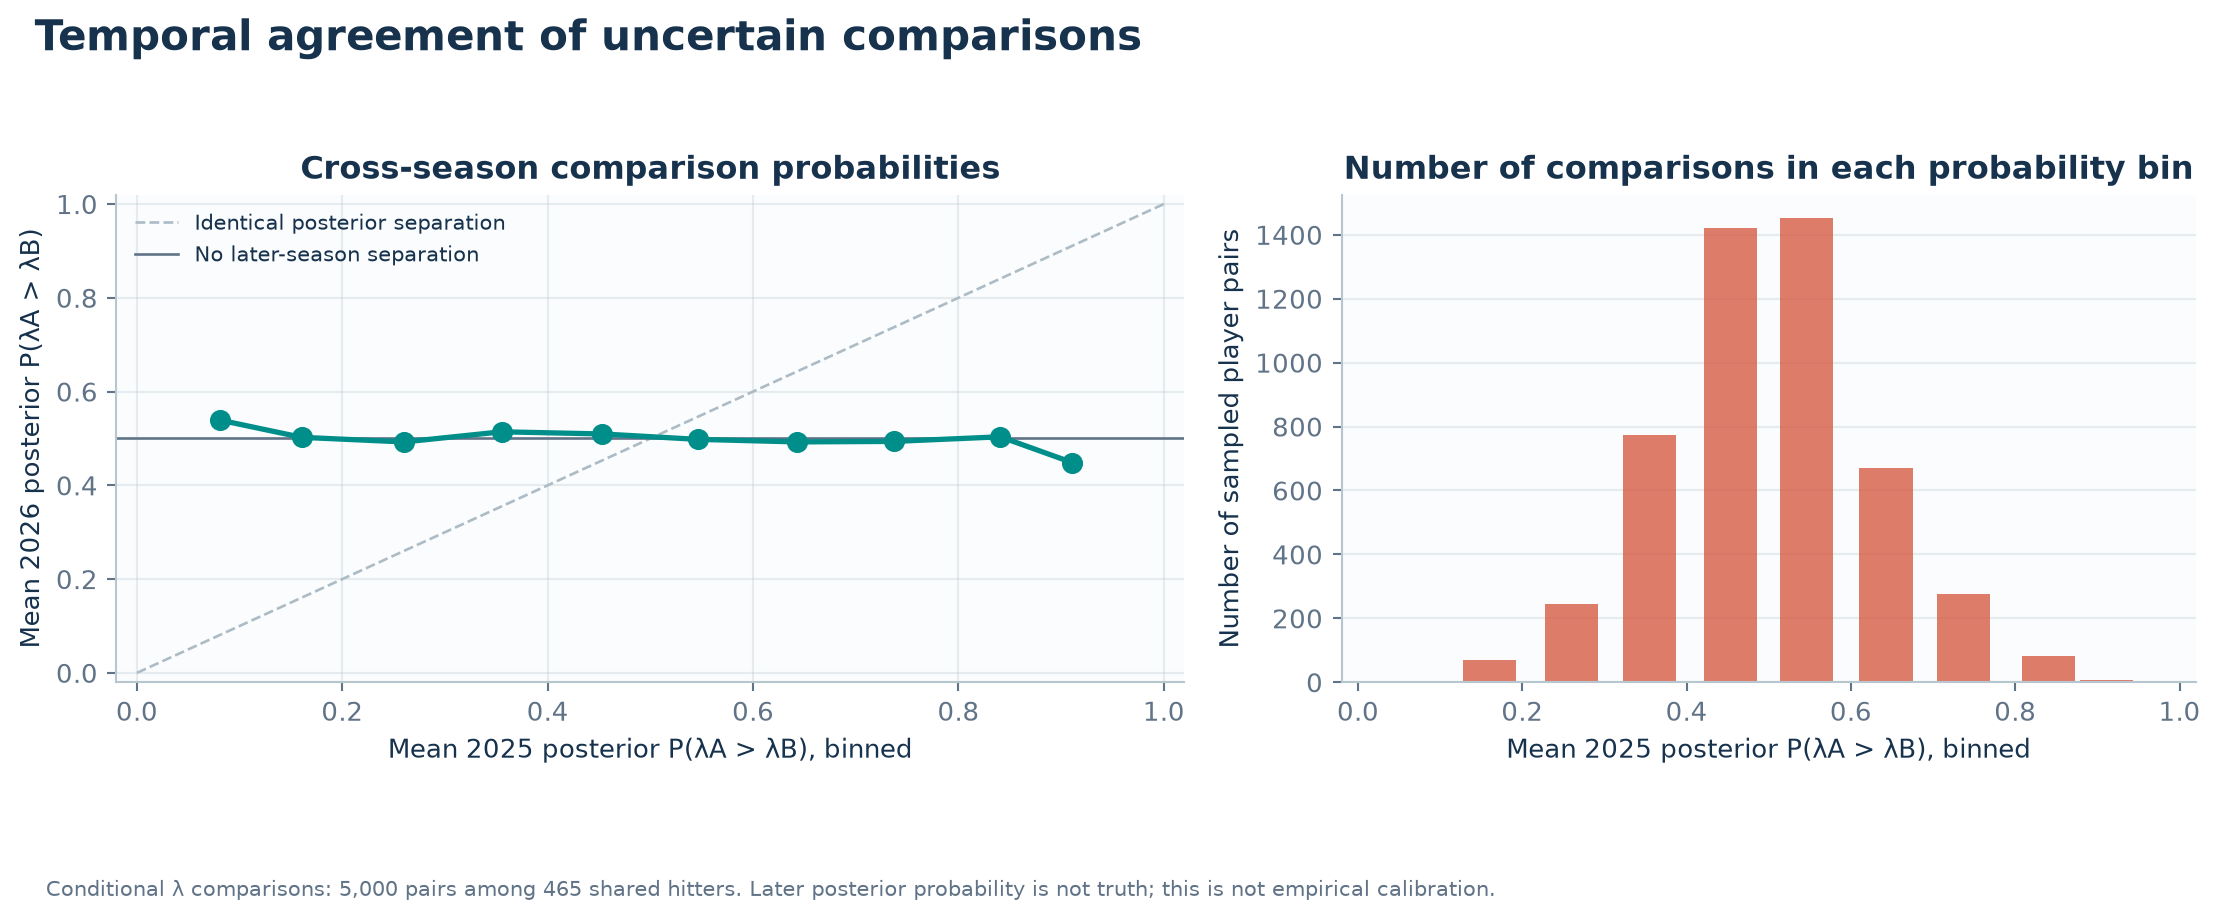

,n_pairs,mean_probability_2025,mean_probability_2026,mean_probability_same_order
0,3,0.0810,0.5390,0.4676
1,68,0.1604,0.5024,0.4957
2,246,0.2602,0.4925,0.5046
3,773,0.3551,0.5141,0.4967
4,1422,0.4532,0.5096,0.4988
5,1453,0.5460,0.4980,0.4993
6,670,0.6425,0.4926,0.4979
7,277,0.7371,0.4936,0.4971
8,82,0.8408,0.5035,0.5030
9,6,0.9108,0.4485,0.4577


In [22]:
show_figure("14_temporal_pairwise_agreement")
display(table("temporal_pairwise_agreement.csv")[["n_pairs", "mean_probability_2025",
    "mean_probability_2026", "mean_probability_same_order"]])

### Within-year reliability

The supplementary 2025 check splits complete games at July 1 and applies the same 40-swing, eight-game eligibility rule to each half. The measurement-error likelihood adjusts for approximate slope SEs. Shared nuisance functions mean the halves are not fully independent. This evaluates conditional split-half reliability and does not provide a prospective forecast. A boundary correlation must be read as weakly identified. The [supplementary report](../paper/supplementary_validation.md) also includes descriptive pitcher sequence diagnostics with game-bootstrap intervals.

In [23]:
split_half = document("results/tables/split_half_2025_persistence.json")
display(pd.Series({key: split_half[key] for key in ["n_players", "split_date",
    "latent_correlation", "bootstrap_ci90", "boundary_fit", "weak_identification", "bootstrap_successes"]},
    name="Within-2025 reliability").to_frame())
if split_half.get("weak_identification"):
    display(Markdown("**The split-half correlation is weakly identified.** The likelihood profile "
        "and bootstrap support a wide range of correlations. The point estimate "
        "does not establish reliable individual differences."))

,Within-2025 reliability
n_players,406
split_date,2025-07-01
latent_correlation,0.0118
bootstrap_ci90,"[-0.9989995977858408, 0.9989995977858408]"
boundary_fit,False
weak_identification,True
bootstrap_successes,100


**The split-half correlation is weakly identified.** The likelihood profile and bootstrap support a wide range of correlations. The point estimate does not establish reliable individual differences.

### Exploratory later-season performance

The next table compares regressions using prior performance and swing summaries with otherwise identical regressions that add the 2025 posterior mean correction association. Each player's outcome is held out during fitting, but the regressions **use other players' 2026 outcomes** as training targets. This is a **player-held-out association test**. It is not a forecast available before 2026.

The analysis uses point estimates without propagating adaptation measurement error. Its xwOBA endpoint is restricted to recorded batted balls. These exploratory results have a different validation scope from the independently specified temporal transport test above.

In [24]:
future_performance = table("future_performance.csv")
display(future_performance[["target", "model", "n_players", "mse"]])

,target,model,n_players,mse
0,whiff,prior_performance,404,0.0012
1,whiff,plus_adaptation,404,0.0012
2,xwoba,prior_performance,404,0.0017
3,xwoba,plus_adaptation,404,0.0017


## 11. Exploratory percentile stability

This section was specified after the original 2026 results had been inspected. It examines the proposal that relative player positions or broad percentile groups may be more stable than slope magnitudes. It is a post-holdout exploratory analysis.

Full-sample comparisons use all available observations in each season; the 2026 snapshot ends on September 20 and does not cover the complete season.

Converting a score to its percentile preserves its order and therefore its Spearman correlation. Partial pooling can change the order because players have different estimation precision. Different outcomes and exposure definitions can also measure different associations. The search compares 84 specifications, two score implementations, and five endpoints, retaining every result. The endpoints are Spearman correlation, Kendall correlation, quartile trend, decile trend, and top-quartile retention. Multiplicity adjustments cover the complete full-sample endpoint family.

The next cell checks percentile invariance using the actual primary player estimates. The saved search also includes six sensitivities requiring at least 500 contributing swings in each season.

,Exploratory rank search
Correlation of slope ranks,-0.0507
Correlation after percentile conversion,-0.0507
Specifications,84.0000
Full-sample endpoint tests,840.0000
Positive non-control Spearman results with BH q ≤ 0.05,11.0000


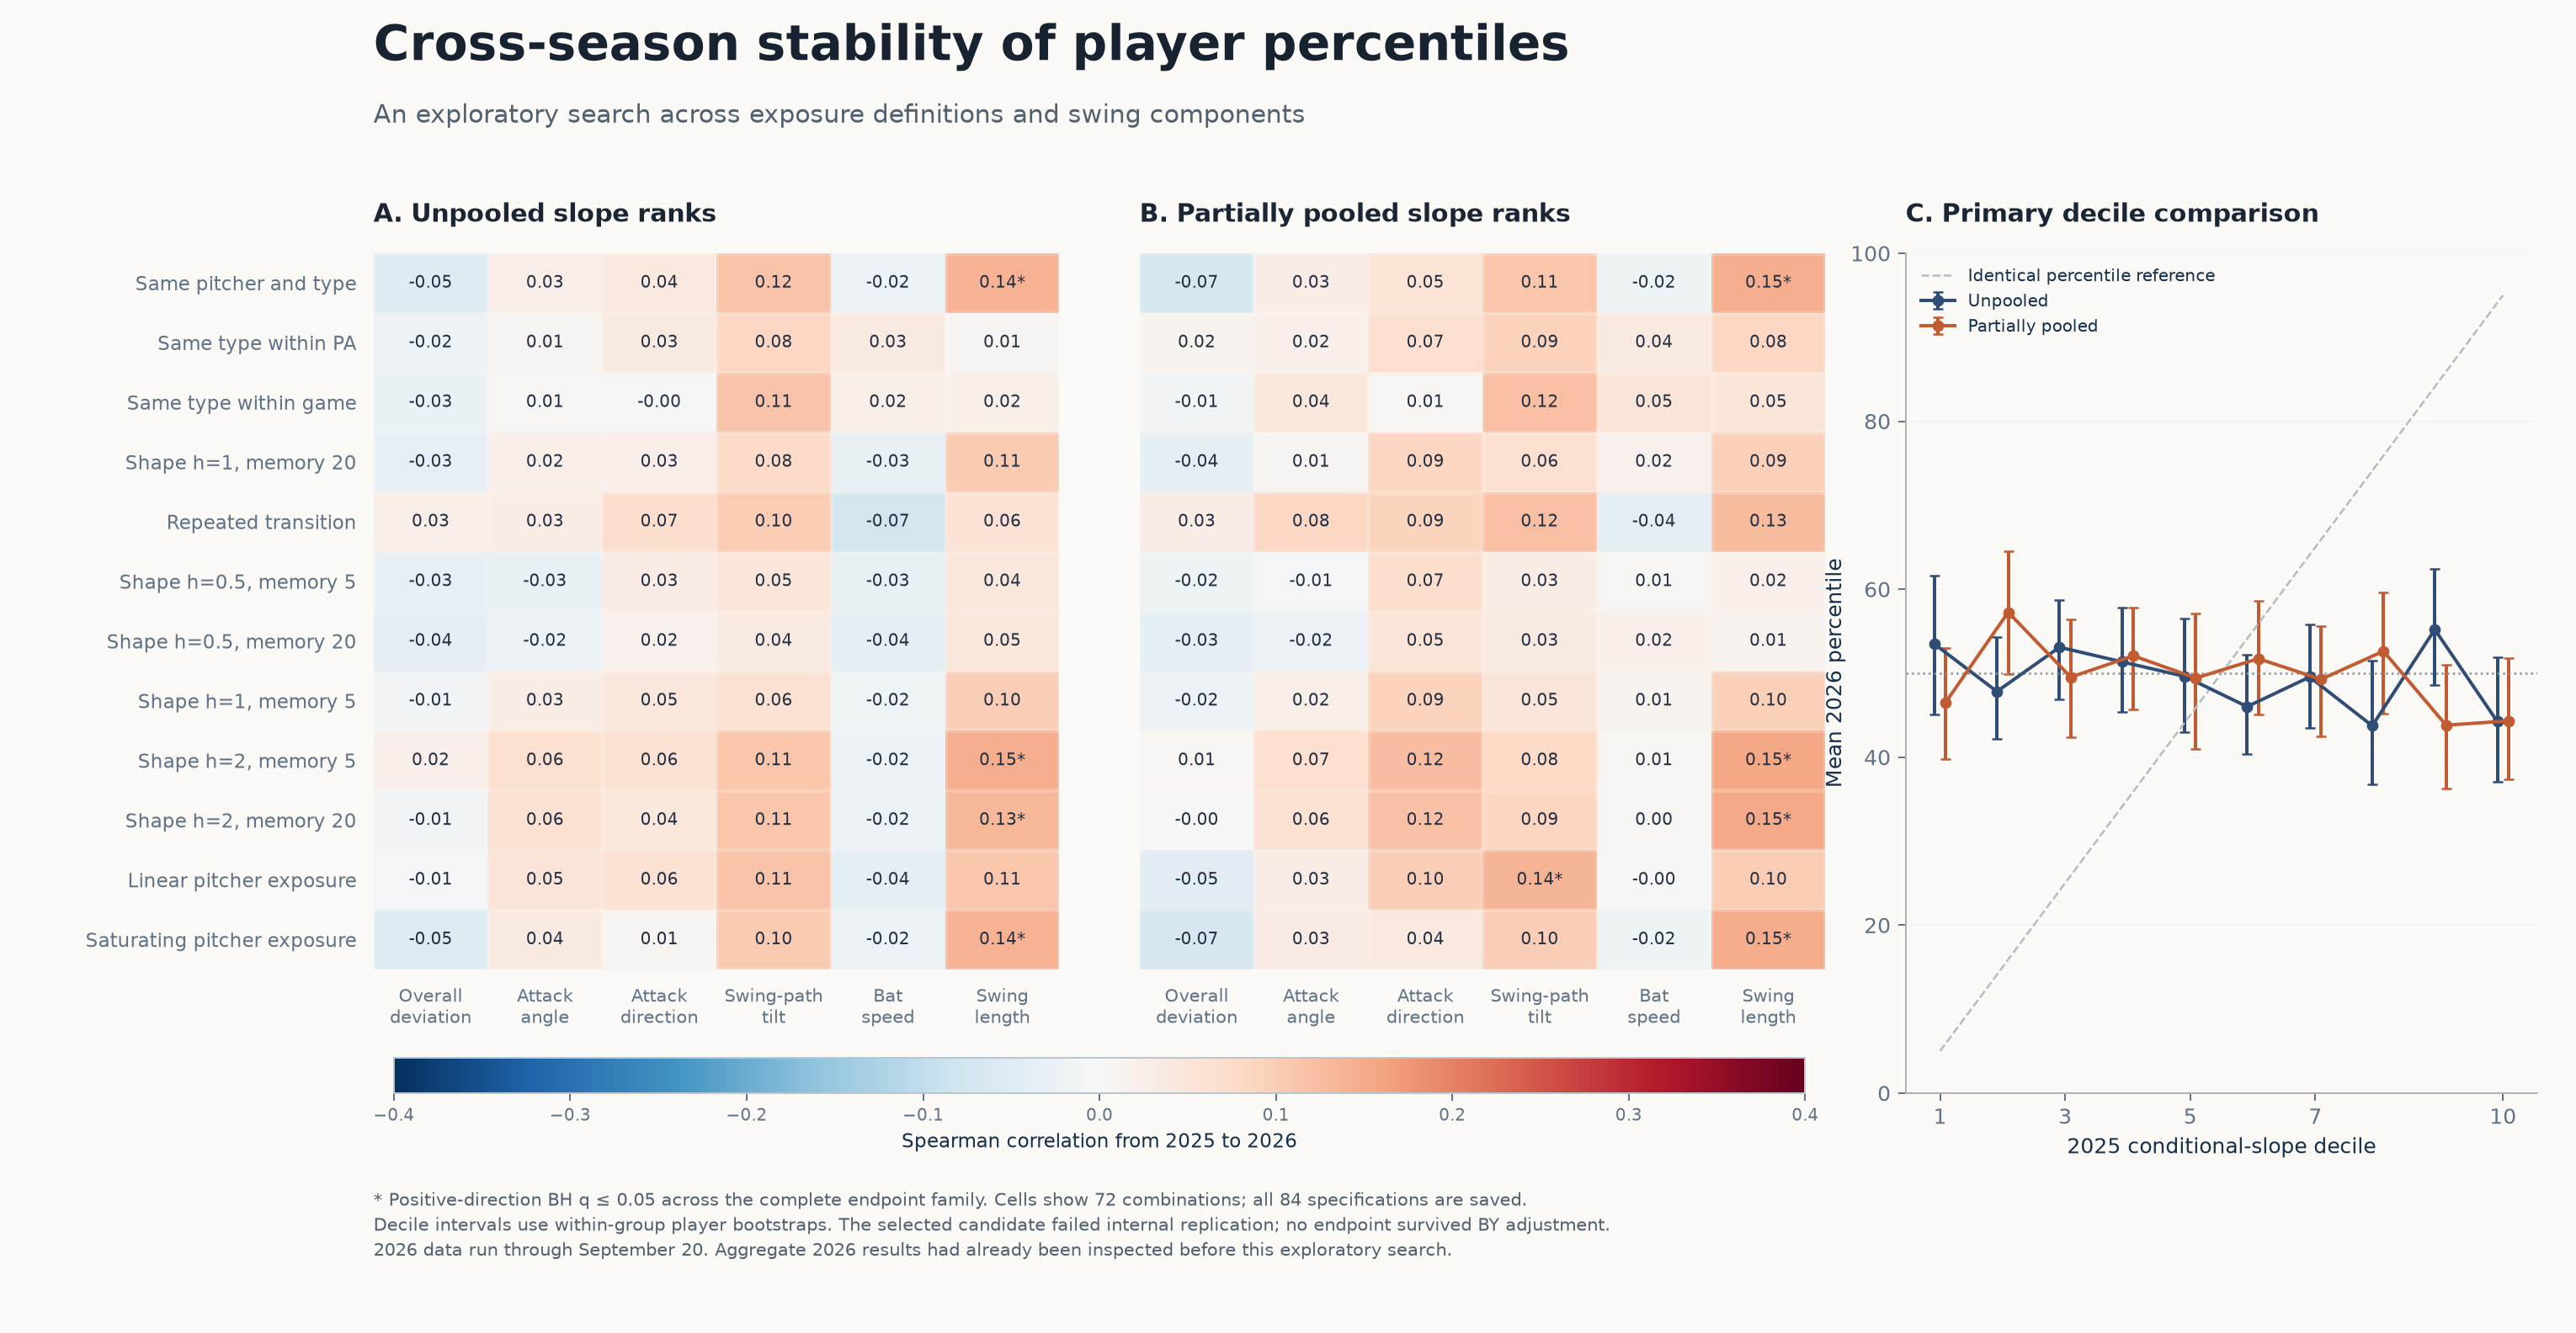

In [25]:
from scipy.stats import spearmanr
percentile_results = table("percentile_stability.csv")
percentile_summary = document("results/tables/percentile_stability_summary.json")
rank_pairs = pd.read_csv(ROOT / "results/tables/percentile_full_year_pairs.csv.gz")
PRIMARY_SPEC = "distortion__log_exposure_pitcher"
example_pairs = rank_pairs.loc[rank_pairs.specification.eq(PRIMARY_SPEC)]
raw_rho = spearmanr(example_pairs.estimate_a, example_pairs.estimate_b).statistic
percentile_rho = spearmanr(example_pairs.estimate_a.rank(pct=True),
                           example_pairs.estimate_b.rank(pct=True)).statistic
assert np.isclose(raw_rho, percentile_rho)
display(pd.Series({"Correlation of slope ranks": raw_rho,
                   "Correlation after percentile conversion": percentile_rho,
                   "Specifications": percentile_summary["specifications"],
                   "Full-sample endpoint tests": percentile_summary["full_year_tests"],
                   "Positive non-control Spearman results with BH q ≤ 0.05":
                       percentile_summary["positive_spearman_bh_significant"]},
                  name="Exploratory rank search").to_frame())
show_figure("percentile_stability")

### Internal replication and the complete search

Candidate selection used March through June in both years. The selection rule chose one positive non-control Spearman result using adjusted significance, then the permutation p value and correlation. That candidate was then evaluated on July through September in both years, alongside the primary score. These are disjoint games, but their observations had contributed to previous full-sample analyses and share fitted nuisance functions. This is an internal replication check, not an untouched test sample.

The first table reports this selected candidate and its internal replication. The second shows the strongest full-sample rank results with their multiplicity corrections. Full-sample results were computed after the candidate was fixed and cannot replace it retrospectively. Bootstrap intervals are pointwise and condition on estimated scores. Stable sample sizes and standard errors can contribute to pooled-rank associations.

In [26]:
selection = document("results/tables/percentile_selection.json")["selected"]
discovery = table("percentile_discovery.csv")
confirmation = table("percentile_confirmation.csv")
if selection is not None:
    selected_rows = pd.concat([
        discovery.loc[discovery.specification.eq(selection["specification"]) &
                      discovery.method.eq(selection["method"])],
        confirmation.loc[confirmation.specification.eq(selection["specification"]) &
                         confirmation.method.eq(selection["method"])]])
    display(selected_rows[["stage", "specification", "method", "shared_players",
                           "estimate", "ci90_low", "ci90_high", "bh_q_positive"]])
rank_results = percentile_results.loc[percentile_results.endpoint.eq("spearman") &
                                      ~percentile_results.negative_control]
display(rank_results.sort_values(["bh_q_positive", "estimate"], ascending=[True, False])
        [["specification", "method", "shared_players", "estimate", "ci90_low",
          "ci90_high", "bh_q_positive", "by_q_positive"]].head(12))
display(Markdown("The [full percentile report](../paper/percentile_stability.md) documents "
                 "all specifications, null results, inference limits, and reproduction commands."))

,stage,specification,method,shared_players,estimate,ci90_low,ci90_high,bh_q_positive
134,discovery,absz_swing_length__log_kernel_h1_m5,unpooled,368,0.1806,0.0936,0.2621,0.0351
2,confirmation,absz_swing_length__log_kernel_h1_m5,unpooled,367,-0.0123,-0.0926,0.0761,0.7736


,specification,method,shared_players,estimate,ci90_low,ci90_high,bh_q_positive,by_q_positive
685,absz_swing_length__log_kernel_h2_m5,pooled,465,0.1532,0.0805,0.2292,0.0339,0.2476
695,absz_swing_length__log_kernel_h2_m20,pooled,465,0.1507,0.0743,0.2237,0.0339,0.2476
715,absz_swing_length__saturating_exposure_pitcher,pooled,460,0.1490,0.0718,0.2281,0.0339,0.2476
680,absz_swing_length__log_kernel_h2_m5,unpooled,465,0.1465,0.0688,0.2234,0.0339,0.2476
605,absz_swing_length__log_exposure_pitcher,pooled,465,0.1454,0.0666,0.2212,0.0339,0.2476
710,absz_swing_length__saturating_exposure_pitcher,unpooled,460,0.1383,0.0615,0.2183,0.0339,0.2476
600,absz_swing_length__log_exposure_pitcher,unpooled,465,0.1383,0.0628,0.2152,0.0352,0.2573
690,absz_swing_length__log_kernel_h2_m20,unpooled,465,0.1322,0.0499,0.2083,0.0352,0.2573
465,absz_swing_path_tilt__linear_exposure_pitcher,pooled,465,0.1366,0.0585,0.2084,0.0430,0.3144
835,absz_swing_length__log_exposure_pitcher__n500,pooled,203,0.1947,0.0864,0.3070,0.0437,0.3194


The [full percentile report](../paper/percentile_stability.md) documents all specifications, null results, inference limits, and reproduction commands.

## 12. Interpretation and limitations

The research assessment generated from the saved results follows below. It distinguishes aggregate exposure associations from evidence of persistent individual skill. The project cannot claim an identified motor-learning rate from observational pitch histories alone.

Limitations include tracking selection, endogenous pitcher strategy, residual confounding, the interpretation of a deviation from an expected swing, finite-cluster slope approximations, and incomplete propagation of baseline-model uncertainty. Memory-kernel comparisons do not by themselves estimate a personal forgetting rate. Synthetic recovery cannot establish causal identification or calibration in MLB data.

In [27]:
notes = ROOT / "paper/results_notes.md"
if notes.exists():
    results_text = notes.read_text()
    for filename in ["percentile_stability.md", "supplementary_validation.md", "matched_comparisons.md"]:
        results_text = results_text.replace(f"]({filename})", f"](../paper/{filename})")
    display(Markdown(results_text))
else:
    display(Markdown("Read the generated tables above. No research conclusion is substituted for missing results notes."))

print("Reproduction artifacts:")
for folder in ["data/checksums.json", "results/tables", "results/posterior", "results/figures", "paper/abstract.md"]:
    print(" •", folder)

# Computed results and scientific status

Analyzed **2,433,934 pitch-level records across 8,271 games**, 2023-07-14 through 2026-09-20. The primary parameter is a conditional exposure association, not a causal learning rate.

| Period | Eligible hitters | Population correction association | 90% credible interval |
|---|---:|---:|---:|
| 2025 | 587 | 0.0351 | [0.0276, 0.0427] |
| 2026 | 591 | 0.0298 | [0.0224, 0.0374] |

Measurement-error-adjusted cross-season correlation: **-0.282**, 90% player-bootstrap interval **[-0.999, 0.355]**, across 465 shared hitters. The interval crosses zero; 14/100 bootstrap fits have |correlation| > 0.98. These are descriptive bootstrap percentiles and may not have nominal coverage near boundaries.

Knowing individual 2025 slopes **increases** 2026 conditional prediction MSE by **0.0047%**, 90% interval **[0.0011%, 0.0081%]**. This centers within heldout hitters and tests slope transport, not prospective raw-swing forecasting.

Negative controls must be read alongside the primary result:

| 2026 exposure specification | Mean correction association | 90% interval |
|---|---:|---:|
| future_exposure | -0.0559 | [-0.0620, -0.0494] |
| irrelevant_exposure | -0.0040 | [-0.0108, 0.0032] |
| shuffled_within_batter_game | 0.0070 | [0.0004, 0.0141] |

In 60 heterogeneous-rate experiments, nominal 90% intervals covered **87.89%** of known rates. Partial pooling lowered RMSE from **0.0691** to **0.0548**. In zero-learning experiments, the population 90% interval excluded zero **4/60** times. This validates only the simulated model; coverage is imperfect.

**Primary-model conclusion:** Repeated exposure is associated with modestly reduced swing deviation, but the primary individual slopes do not support a persistent talent metric in this snapshot. Their held-out prediction is slightly worse than the population-slope benchmark. The improvement in whiff classification provides evidence that contemporaneous mechanics contain predictive information. It does not establish individual learning speed.

**Exploratory percentile analysis:** The search covered 84 specifications and 840 endpoint tests. There were **11 positive non-control Spearman results with BH q ≤ 0.05**. Sorting by BH q and then decreasing correlation gives `absz_swing_length__log_kernel_h2_m5` (pooled): correlation **0.153**, pointwise 90% interval **[0.080, 0.229]**, BH q=0.0339, BY q=0.2476. This is a result from the searched family.

The component findings concentrate in swing length. Among 203 hitters with at least 500 contributing swings in each season, the partially pooled swing-length score had correlation **0.195**, 90% interval **[0.086, 0.307]**, BH q=0.0437. However, **0 non-control rank results pass BY q ≤ 0.05**, and the structurally related future-exposure control is similarly stable: correlation **0.156**, interval **[0.076, 0.225]**, BH q=0.0339. These patterns do not isolate adaptation from stable selection or model structure.

The candidate selected from early-season partitions was `absz_swing_length__log_kernel_h1_m5` (unpooled): Spearman **0.181**, BH q=0.0351. In the later-season internal replication, its correlation was **-0.012**, 90% interval **[-0.093, 0.076]**, BH q=0.7736. The selected relationship did not replicate. Percentile conversion alone leaves Spearman correlation unchanged. The search was specified after inspecting the original 2026 analysis; its findings are exploratory. Full-sample associations cannot establish persistent latent skill without replication. See the [complete percentile report](../paper/percentile_stability.md).

## Sequence information

| season | component | n | rmse_current | rmse_history | mse_gain_pct | gain_ci90_low | gain_ci90_high |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2024 | attack_angle | 159801 | 8.7474 | 8.7422 | 0.11742 | 0.062765 | 0.18326 |
| 2024 | attack_direction | 159801 | 13.87 | 13.875 | -0.069787 | -0.13468 | 0.0056848 |
| 2024 | swing_path_tilt | 159801 | 3.639 | 3.6415 | -0.13937 | -0.25621 | -0.0092801 |
| 2024 | bat_speed | 159801 | 6.5471 | 6.5487 | -0.051115 | -0.11013 | 0.0083361 |
| 2024 | swing_length | 159801 | 0.54873 | 0.54854 | 0.070909 | -0.0043911 | 0.15189 |
| 2025 | attack_angle | 328151 | 8.9513 | 8.9512 | 0.0013967 | -0.039677 | 0.042751 |
| 2025 | attack_direction | 328151 | 14.05 | 14.053 | -0.041514 | -0.086806 | 0.0029969 |
| 2025 | swing_path_tilt | 328151 | 4.0372 | 4.0412 | -0.19631 | -0.28816 | -0.10472 |
| 2025 | bat_speed | 328151 | 6.7873 | 6.7899 | -0.078832 | -0.11637 | -0.034437 |
| 2025 | swing_length | 328151 | 0.58124 | 0.58059 | 0.2253 | 0.17048 | 0.28234 |
| 2026 | attack_angle | 316797 | 9.0212 | 9.0098 | 0.25252 | 0.20912 | 0.2978 |
| 2026 | attack_direction | 316797 | 14.188 | 14.194 | -0.086053 | -0.1362 | -0.03015 |
| 2026 | swing_path_tilt | 316797 | 4.3115 | 4.3048 | 0.31101 | 0.21153 | 0.42391 |
| 2026 | bat_speed | 316797 | 6.917 | 6.9137 | 0.094067 | 0.048012 | 0.14242 |
| 2026 | swing_length | 316797 | 0.6069 | 0.60649 | 0.13556 | 0.077413 | 0.19348 |

## Whiff classification

| model | train_season | test_season | test_n | log_loss | auc |
| --- | --- | --- | --- | --- | --- |
| current_pitch | 2025 | 2026 | 316713 | 0.43728 | 0.78132 |
| plus_swing_deviations | 2025 | 2026 | 316713 | 0.4095 | 0.81706 |

## Exploratory later-season outcomes

| target | model | n_players | mse | scope |
| --- | --- | --- | --- | --- |
| whiff | prior_performance | 404 | 0.0012008 | Exploratory player-held-out regression predicting 2026 from 2025; no measurement-error propagation; xwOBA among batted balls only. |
| whiff | plus_adaptation | 404 | 0.0012031 | Exploratory player-held-out regression predicting 2026 from 2025; no measurement-error propagation; xwOBA among batted balls only. |
| xwoba | prior_performance | 404 | 0.0016874 | Exploratory player-held-out regression predicting 2026 from 2025; no measurement-error propagation; xwOBA among batted balls only. |
| xwoba | plus_adaptation | 404 | 0.0016917 | Exploratory player-held-out regression predicting 2026 from 2025; no measurement-error propagation; xwOBA among batted balls only. |

## Complete sensitivity results

| specification | season | players | mu_median | mu_low | mu_high | p_mu_positive | tau_median | tau_low | tau_high |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| exposure_pitcher | 2025 | 587 | 0.035075 | 0.02764 | 0.042735 | 1 | 0.036065 | 0.019251 | 0.049237 |
| exposure_pa | 2025 | 587 | 0.03067 | 0.017962 | 0.044257 | 0.99967 | 0.073883 | 0.051653 | 0.094827 |
| exposure_type | 2025 | 587 | 0.025308 | 0.019526 | 0.031478 | 1 | 0.032092 | 0.021137 | 0.041962 |
| kernel_exposure | 2025 | 587 | 0.055319 | 0.045419 | 0.065822 | 1 | 0.058908 | 0.042244 | 0.074789 |
| exposure_sequence | 2025 | 587 | 0.025282 | 0.017614 | 0.033436 | 1 | 0.044631 | 0.030875 | 0.057505 |
| future_exposure | 2025 | 587 | -0.045926 | -0.052285 | -0.039267 | 0 | 0.048737 | 0.040836 | 0.057218 |
| irrelevant_exposure | 2025 | 587 | -0.0051979 | -0.011328 | 0.0013527 | 0.096667 | 0.031192 | 0.017153 | 0.042439 |
| kernel_h0.5_m5 | 2025 | 586 | 0.076592 | 0.061794 | 0.092232 | 1 | 0.091069 | 0.06755 | 0.11406 |
| kernel_h0.5_m20 | 2025 | 587 | 0.05681 | 0.045586 | 0.068616 | 1 | 0.068984 | 0.051418 | 0.08624 |
| kernel_h1_m5 | 2025 | 586 | 0.076482 | 0.063279 | 0.090502 | 1 | 0.080421 | 0.058707 | 0.10138 |
| kernel_h2_m5 | 2025 | 587 | 0.077869 | 0.065989 | 0.090577 | 1 | 0.067656 | 0.046026 | 0.087483 |
| kernel_h2_m20 | 2025 | 587 | 0.055538 | 0.046559 | 0.065113 | 1 | 0.051622 | 0.035806 | 0.066338 |
| linear_exposure_pitcher | 2025 | 587 | 0.011058 | 0.0085869 | 0.013687 | 1 | 0.01492 | 0.010941 | 0.018823 |
| saturating_exposure_pitcher | 2025 | 582 | 0.076399 | 0.06072 | 0.093054 | 1 | 0.077909 | 0.042108 | 0.10658 |
| component:attack_angle | 2025 | 587 | 0.023212 | 0.01835 | 0.028397 | 1 | 0.02192 | 0.0081698 | 0.031913 |
| component:attack_direction | 2025 | 587 | 0.023243 | 0.018338 | 0.028483 | 1 | 0.023389 | 0.0094506 | 0.033578 |
| component:swing_path_tilt | 2025 | 587 | 0.013171 | 0.0076481 | 0.018959 | 0.99967 | 0.03771 | 0.029948 | 0.045768 |
| component:bat_speed | 2025 | 587 | 0.011579 | 0.0063438 | 0.017193 | 0.99933 | 0.017063 | 0.0029252 | 0.029343 |
| component:swing_length | 2025 | 587 | 0.022413 | 0.01728 | 0.027889 | 1 | 0.026652 | 0.014947 | 0.03624 |
| shuffled_within_batter_game | 2025 | 587 | 0.0074526 | 0.00054694 | 0.014849 | 0.96567 | 0.018432 | 0.0024541 | 0.036051 |
| similar_shape_recent | 2025 | 551 | 0.039189 | 0.029016 | 0.049797 | 1 | 0.053965 | 0.032991 | 0.071944 |
| competitive_swing_speed_50 | 2025 | 587 | 0.020399 | 0.014052 | 0.02712 | 1 | 0.036376 | 0.025693 | 0.046506 |
| early_in_game | 2025 | 574 | 0.035037 | 0.026639 | 0.043986 | 1 | 0.049611 | 0.035323 | 0.063224 |
| first_three_innings | 2025 | 490 | 0.029335 | 0.015631 | 0.043889 | 0.999 | 0.076722 | 0.052721 | 0.099505 |
| prior_tau_scale:0.075 | 2025 | 587 | 0.035057 | 0.027822 | 0.042746 | 1 | 0.035808 | 0.019278 | 0.04902 |
| prior_tau_scale:0.3 | 2025 | 587 | 0.035056 | 0.027807 | 0.04276 | 1 | 0.036247 | 0.019932 | 0.049433 |
| exposure_pitcher | 2026 | 591 | 0.029821 | 0.022368 | 0.037352 | 1 | 0.045755 | 0.033375 | 0.057545 |
| exposure_pa | 2026 | 590 | 0.028935 | 0.016137 | 0.042543 | 0.99967 | 0.083771 | 0.063821 | 0.10378 |
| exposure_type | 2026 | 591 | 0.018821 | 0.012842 | 0.025175 | 1 | 0.037156 | 0.027809 | 0.04639 |
| kernel_exposure | 2026 | 591 | 0.048266 | 0.038718 | 0.058382 | 1 | 0.057115 | 0.039789 | 0.073414 |
| exposure_sequence | 2026 | 591 | 0.023166 | 0.015674 | 0.03108 | 1 | 0.033825 | 0.012849 | 0.049132 |
| future_exposure | 2026 | 591 | -0.055875 | -0.062032 | -0.049406 | 0 | 0.043979 | 0.035462 | 0.052865 |
| irrelevant_exposure | 2026 | 591 | -0.0040486 | -0.010845 | 0.0031941 | 0.17533 | 0.052275 | 0.043342 | 0.061685 |
| kernel_h0.5_m5 | 2026 | 587 | 0.064891 | 0.050764 | 0.079789 | 1 | 0.076956 | 0.046839 | 0.10287 |
| kernel_h0.5_m20 | 2026 | 591 | 0.051209 | 0.040472 | 0.062468 | 1 | 0.06045 | 0.039082 | 0.079567 |
| kernel_h1_m5 | 2026 | 590 | 0.062959 | 0.050407 | 0.076334 | 1 | 0.071635 | 0.047225 | 0.09375 |
| kernel_h2_m5 | 2026 | 591 | 0.063873 | 0.052279 | 0.076146 | 1 | 0.068945 | 0.048713 | 0.088251 |
| kernel_h2_m20 | 2026 | 591 | 0.047976 | 0.039139 | 0.057321 | 1 | 0.055437 | 0.041038 | 0.069608 |
| linear_exposure_pitcher | 2026 | 591 | 0.0098064 | 0.0072508 | 0.012479 | 1 | 0.017218 | 0.013585 | 0.020964 |
| saturating_exposure_pitcher | 2026 | 584 | 0.065423 | 0.04979 | 0.081812 | 1 | 0.0959 | 0.068973 | 0.12168 |
| component:attack_angle | 2026 | 591 | 0.026132 | 0.021689 | 0.030903 | 1 | 0.0095288 | 0.0010995 | 0.02175 |
| component:attack_direction | 2026 | 591 | 0.025831 | 0.020731 | 0.031232 | 1 | 0.034151 | 0.026848 | 0.041659 |
| component:swing_path_tilt | 2026 | 591 | 0.017974 | 0.012834 | 0.023338 | 1 | 0.030413 | 0.021927 | 0.038671 |
| component:bat_speed | 2026 | 591 | 0.010407 | 0.0053494 | 0.015801 | 0.999 | 0.023663 | 0.0092681 | 0.034221 |
| component:swing_length | 2026 | 591 | 0.024973 | 0.019507 | 0.030785 | 1 | 0.038458 | 0.030265 | 0.046861 |
| shuffled_within_batter_game | 2026 | 591 | 0.0070114 | 0.00036052 | 0.01407 | 0.96033 | 0.024787 | 0.0049207 | 0.040719 |
| similar_shape_recent | 2026 | 538 | 0.036175 | 0.02631 | 0.046481 | 1 | 0.051258 | 0.031428 | 0.068243 |
| competitive_swing_speed_50 | 2026 | 589 | 0.017829 | 0.011747 | 0.024188 | 1 | 0.034042 | 0.023264 | 0.044078 |
| early_in_game | 2026 | 557 | 0.032885 | 0.024647 | 0.041607 | 1 | 0.052596 | 0.039852 | 0.065278 |
| first_three_innings | 2026 | 496 | 0.036861 | 0.023803 | 0.050678 | 1 | 0.067649 | 0.041257 | 0.090755 |
| prior_tau_scale:0.075 | 2026 | 591 | 0.029803 | 0.022529 | 0.037414 | 1 | 0.045515 | 0.033361 | 0.057318 |
| prior_tau_scale:0.3 | 2026 | 591 | 0.029794 | 0.022504 | 0.037422 | 1 | 0.045916 | 0.033794 | 0.057734 |

## Scope

Consult methods_notes.md and the executed notebook. These results do not identify causal motor learning. Statistical heterogeneity and narrow player intervals do not by themselves establish persistent adaptation or coaching utility. Negative-control failure weakens the interpretation even if a population association is precisely estimated.

Future exposure is structurally related to past exposure through the total number of same-type pitches in a game. Its opposite-sign association highlights timing and selection sensitivity; it is not an independent randomized placebo and does not prove that hitters never learn. Shuffling exposure residuals within hitter-game retains between-game structure, so its remaining association warns about that component of the primary estimate.

## Matched current-pitch restriction

| season | outcome | n_input_swings | n_covariate_eligible_swings | n_pairs | n_pairs_with_outcome | games | players | fraction_eligible_swings_matched | mean_exposure_increment | mean_change_later_minus_earlier | ci90_low | ci90_high | bootstrap_replicates |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 2025 | distortion | 328082 | 328082 | 752 | 752 | 639 | 366 | 0.0045842 | 1.7713 | -0.046974 | -0.10581 | 0.012304 | 2000 |
| 2025 | adj_distortion | 328082 | 328082 | 752 | 752 | 639 | 366 | 0.0045842 | 1.7713 | -0.039378 | -0.098103 | 0.019975 | 2000 |
| 2026 | distortion | 316713 | 316713 | 668 | 668 | 565 | 353 | 0.0042183 | 1.7425 | -0.077934 | -0.14286 | -0.010881 | 2000 |
| 2026 | adj_distortion | 316713 | 316713 | 668 | 668 | 565 | 353 | 0.0042183 | 1.7425 | -0.073442 | -0.13869 | -0.0064724 | 2000 |

## Whiff-conditional miss distance

| season | n_whiffs | n_players | mu_median | mu_low | mu_high | scope |
| --- | --- | --- | --- | --- | --- | --- |
| 2025 | 77033 | 479 | 0.063367 | 0.05166 | 0.075747 | Conditional on tracked whiffs; contacts are missing, not zero. Log-distance normalized to 2025 SD; not unconditional mechanical learning. |
| 2026 | 73608 | 477 | 0.051698 | 0.040915 | 0.063242 | Conditional on tracked whiffs; contacts are missing, not zero. Log-distance normalized to 2025 SD; not unconditional mechanical learning. |

See [supplementary validation](../paper/supplementary_validation.md) for the weakly identified split-half fit and descriptive pitcher diagnostics, and [matched comparisons](../paper/matched_comparisons.md) for pairing rules, balance and selection.


Reproduction artifacts:
 • data/checksums.json
 • results/tables
 • results/posterior
 • results/figures
 • paper/abstract.md


## Supporting documents

- [Methods and identification notes](../paper/methods_notes.md)
- [Related work and primary sources](../literature/related_work.md)
- [Exploratory percentile analysis](../paper/percentile_stability.md)
- [Data provenance and reconstruction](../data/README.md)
- [Generated SSAC abstract](../paper/abstract.md)
- [Project README and full reproduction commands](../README.md)

Player evaluation or development applications require evidence from negative controls, temporal persistence, and measurement validation. The estimated distributions should be interpreted within those limits.